# User Trust Calibration & Data Analysis

## Overview
In this notebook, we analyse the **user responses** (`user_responses.csv`) collected from participants (whose demographics and background are recorded in `user_metadata.csv`) for the questions presented alongside LLM-generated outputs in the **model outputs dataset** (`model_outputs_all_datasets.csv`).

## Objectives
1. **Trust Calibration** – Assess and calibrate user trust in LLM-generated explanations across different datasets and model configurations.
2. **Exploratory Data Analysis** – Investigate patterns, distributions, and relationships within the collected responses to surface meaningful insights.
3. **Emergent Findings** – Let the data guide us toward any additional trends, correlations, or anomalies worth reporting.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns


## Load Data & Convert Numeric Columns
Load the user responses dataset and ensure that scored columns (`trust_score`, `helpfulness_score`, `confidence_alignment`) are cast to proper numeric types, coercing any non-numeric entries to `NaN`.

In [75]:
# Load data
df = pd.read_csv("user_responses.csv")

# Convert numeric columns (important!)
numeric_cols = [
    "trust_score",
    "helpfulness_score",
    "confidence_alignment"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows with missing trust
df = df.dropna(subset=["trust_score"])

print("Total responses:", len(df))

Total responses: 300


## Mean Trust by Preferred Answer Type
Compute and visualise the **average trust score** grouped by participants' preferred answer type. This helps us understand whether users who favour a particular answer style (e.g., model-generated vs. human-written) tend to express systematically higher or lower trust in LLM outputs.


Mean Trust by Preferred Answer:
preferred_answer
Answer only                3.080292
Answer with explanation    3.119403
Disagree with both         0.448276
Name: trust_score, dtype: float64


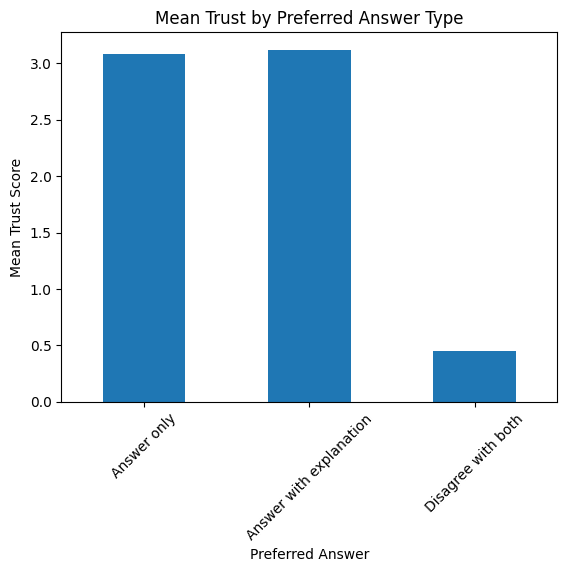

In [76]:
trust_by_pref = df.groupby("preferred_answer")["trust_score"].mean()
print("\nMean Trust by Preferred Answer:")
print(trust_by_pref)

# Bar chart
plt.figure()
trust_by_pref.plot(kind="bar")
plt.title("Mean Trust by Preferred Answer Type")
plt.ylabel("Mean Trust Score")
plt.xlabel("Preferred Answer")
plt.xticks(rotation=45)
plt.show()

## Trust by issue detection
What this tells  -  Do users reduce trust when they detect inconsistency?


Mean Trust by Issue Detection:
noticed_issue
No          3.436047
Not sure    2.377358
Yes         1.813333
Name: trust_score, dtype: float64


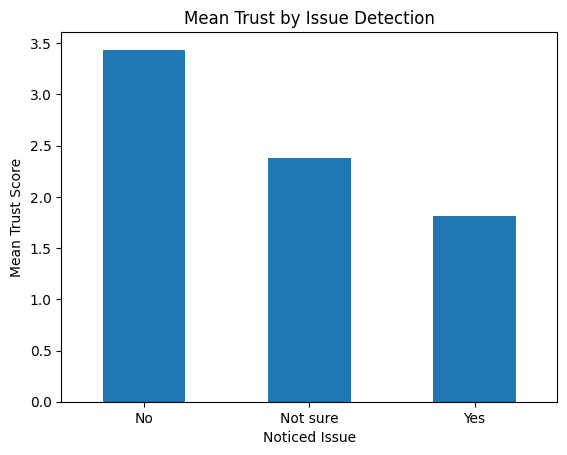

In [77]:
trust_by_issue = df.groupby("noticed_issue")["trust_score"].mean()
print("\nMean Trust by Issue Detection:")
print(trust_by_issue)

plt.figure()
trust_by_issue.plot(kind="bar")
plt.title("Mean Trust by Issue Detection")
plt.ylabel("Mean Trust Score")
plt.xlabel("Noticed Issue")
plt.xticks(rotation=0)
plt.show()

## Confidence vs Trust Correlation

Interpretation:

Close to 1 - strong positive relationship

Around 0  - no relationship

Negative  - inverse effect

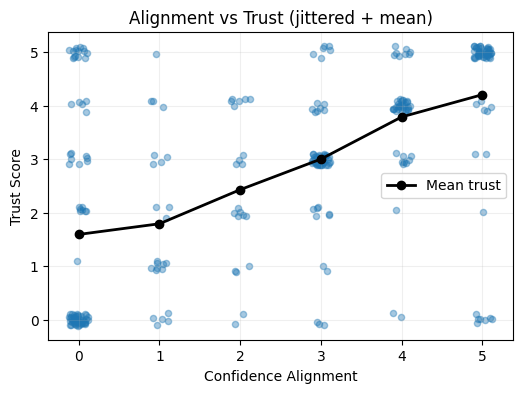

In [78]:


x = df["confidence_alignment"].values
y = df["trust_score"].values

# jitter so overlapping points become visible
xj = x + np.random.uniform(-0.12, 0.12, size=len(x))
yj = y + np.random.uniform(-0.12, 0.12, size=len(y))

plt.figure(figsize=(6,4))
plt.scatter(xj, yj, alpha=0.4, s=20)

means = df.groupby("confidence_alignment")["trust_score"].mean()
plt.plot(means.index, means.values, marker="o", color="black", linewidth=2, label="Mean trust")

plt.xticks(range(6)); plt.yticks(range(6))
plt.xlabel("Confidence Alignment")
plt.ylabel("Trust Score")
plt.title("Alignment vs Trust (jittered + mean)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Lets also do a per user correlation between confidence alignment and trust score, to see if the relationship holds at the individual level.

Because each participant provided multiple ratings (≈15 items), we computed within-participant Spearman correlations between confidence alignment and trust. The distribution of per-user correlations was predominantly positive (median ≈ 0.77; mean ≈ 0.64), indicating that for most participants, higher perceived alignment between model confidence and their own confidence corresponded to higher trust ratings. In contrast, the correlation between participant-level mean alignment and mean trust was weaker (≈0.33), suggesting substantial individual differences in baseline trus

In [79]:
# Spearman per-user correlation
rows = []
skipped = []
for uid, g in df.groupby("user_id"):
    g = g[["confidence_alignment", "trust_score"]].dropna()

    # must have variation in both columns
    if g["confidence_alignment"].nunique() > 1 and g["trust_score"].nunique() > 1:
        corr = g["confidence_alignment"].corr(g["trust_score"], method="spearman")
        rows.append({
            "user_id": uid,
            "n_rows": len(g),
            "spearman_within": corr
        })
    else:
        skipped.append({
            "user_id": uid,
            "n_rows": len(g),
            "unique_conf_align": g["confidence_alignment"].nunique(),
            "unique_trust": g["trust_score"].nunique(),
            "reason": "no variation in confidence_alignment and/or trust_score"
        })

per_user = pd.DataFrame(rows).sort_values("spearman_within", ascending=False)
print(per_user)
print("\nSummary:")
print(per_user["spearman_within"].describe())

if skipped:
    print(f"\n⚠ {len(skipped)} user(s) skipped (constant values → correlation undefined):")
    print(pd.DataFrame(skipped).to_string(index=False))

                 user_id  n_rows  spearman_within
0   user_20260222_140003      15         0.994199
7   user_20260228_105721      15         0.972563
1   user_20260222_142502      15         0.961998
13  user_20260301_162359      15         0.907460
11  user_20260301_030143      15         0.902574
4   user_20260225_043327      15         0.789738
9   user_20260228_134755      15         0.786795
3   user_20260225_042837      15         0.770588
12  user_20260301_050659      15         0.718722
6   user_20260228_095616      15         0.553925
2   user_20260223_162027      15         0.534316
14  user_20260302_085105      15         0.446767
10  user_20260301_014641      15         0.391735
16  user_20260302_113844      15         0.263701
8   user_20260228_132659      15         0.240497
5   user_20260225_050349      15        -0.272458
15  user_20260302_095330      15        -0.301511

Summary:
count    17.000000
mean      0.568330
std       0.402950
min      -0.301511
25%       0.39

## 1. Response Volume by Dataset
How many responses were collected for each dataset? This gives us a sense of balance and whether any dataset is under-represented.

Response count by dataset:
dataset
eSNLI         100
CoSE          100
TruthfulQA    100
Name: count, dtype: int64

Total responses: 300


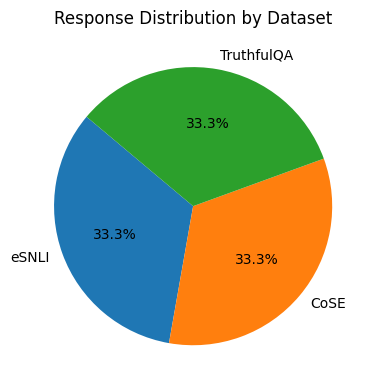

In [80]:
# Response count by dataset
print("Response count by dataset:")
print(df["dataset"].value_counts())
print(f"\nTotal responses: {len(df)}")

# Pie chart of response distribution
plt.figure(figsize=(6, 4))
df["dataset"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=140)
plt.title("Response Distribution by Dataset")
plt.ylabel("")  # hide default ylabel
plt.tight_layout()
plt.show()

## 2. Mean Trust, Helpfulness & Confidence Alignment by Dataset
Compare the average **trust score**, **helpfulness score**, and **confidence alignment** across datasets. This reveals whether users systematically trust LLM outputs more for some question types than others.

Mean scores by dataset:

            trust_score  helpfulness_score  confidence_alignment
dataset                                                         
CoSE               3.16               2.18                  2.36
TruthfulQA         3.10               2.70                  2.91
eSNLI              2.27               2.09                  2.26


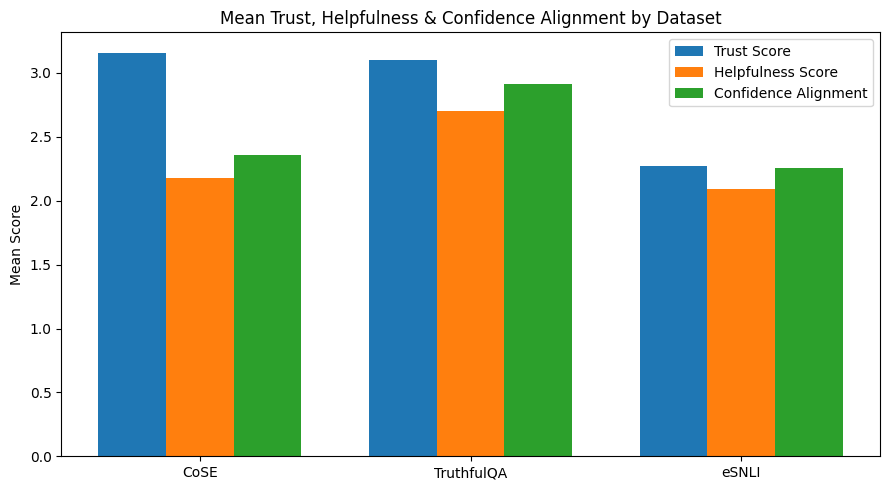

In [81]:
# Mean scores by dataset
score_cols = ["trust_score", "helpfulness_score", "confidence_alignment"]
dataset_means = df.groupby("dataset")[score_cols].mean()
print("Mean scores by dataset:\n")
print(dataset_means.round(3))

# Grouped bar chart
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(dataset_means.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, dataset_means[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(dataset_means.index)
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by Dataset")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Trust Score Distribution by Dataset (Box Plot)
Box plots show the **spread, median, and outliers** of trust scores for each dataset. This is more informative than means alone — it tells us whether one dataset has higher variance or more extreme responses.

C:\Users\madevada\AppData\Local\Temp\ipykernel_45852\914189350.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_ds, labels=datasets)
C:\Users\madevada\AppData\Local\Temp\ipykernel_45852\914189350.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_ds, labels=datasets)
C:\Users\madevada\AppData\Local\Temp\ipykernel_45852\914189350.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(data_by_ds, labels=datasets)


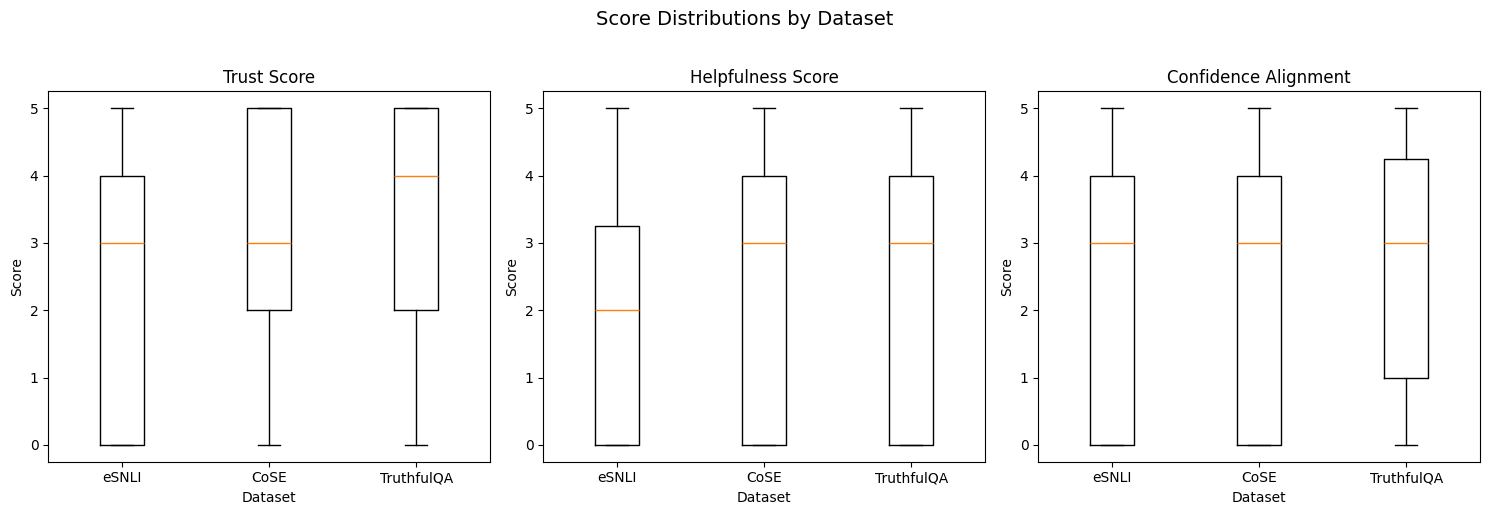

Median scores by dataset:
            trust_score  helpfulness_score  confidence_alignment
dataset                                                         
CoSE                3.0                3.0                   3.0
TruthfulQA          4.0                3.0                   3.0
eSNLI               3.0                2.0                   3.0

Std deviation by dataset:
            trust_score  helpfulness_score  confidence_alignment
dataset                                                         
CoSE              1.698              1.914                 1.872
TruthfulQA        1.840              1.936                 1.837
eSNLI             1.836              1.848                 1.884


In [82]:
# Box plots for trust, helpfulness, and confidence alignment by dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(score_cols):
    datasets = df["dataset"].unique()
    data_by_ds = [df[df["dataset"] == ds][col].dropna() for ds in datasets]
    axes[i].boxplot(data_by_ds, labels=datasets)
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_ylabel("Score")
    axes[i].set_xlabel("Dataset")

fig.suptitle("Score Distributions by Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Also print medians and standard deviations
print("Median scores by dataset:")
print(df.groupby("dataset")[score_cols].median().round(3))
print("\nStd deviation by dataset:")
print(df.groupby("dataset")[score_cols].std().round(3))

## 4. Preferred Answer Type by Dataset
Do users prefer "Answer only" or "Answer with explanation" differently depending on the dataset? This stacked bar chart shows the **proportion of preferred answer types** within each dataset.

Preferred answer % by dataset:

preferred_answer  Answer only  Answer with explanation  Disagree with both
dataset                                                                   
CoSE                     49.0                     42.0                 9.0
TruthfulQA               42.0                     51.0                 7.0
eSNLI                    46.0                     41.0                13.0


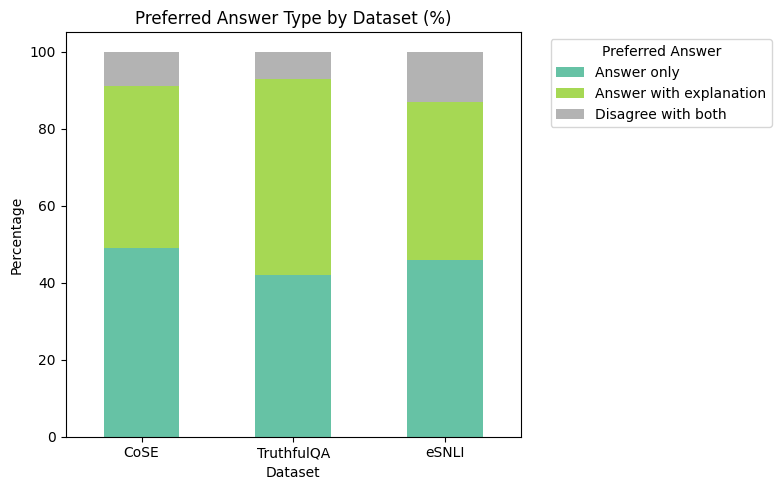

In [83]:
# Preferred answer type breakdown by dataset
pref_by_ds = pd.crosstab(df["dataset"], df["preferred_answer"], normalize="index") * 100
print("Preferred answer % by dataset:\n")
print(pref_by_ds.round(1))

# Stacked bar chart
pref_by_ds.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Preferred Answer Type by Dataset (%)")
plt.ylabel("Percentage")
plt.xlabel("Dataset")
plt.legend(title="Preferred Answer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Issue Detection Rate by Dataset
Users could flag whether they **noticed an issue** with the LLM response. This analysis shows the proportion of responses where issues were flagged, broken down by dataset. A higher issue rate may indicate lower quality LLM outputs for that question type.

Issue detection rate (%) by dataset:

dataset
CoSE          24.0
TruthfulQA    20.0
eSNLI         31.0
Name: issue_flag, dtype: float64


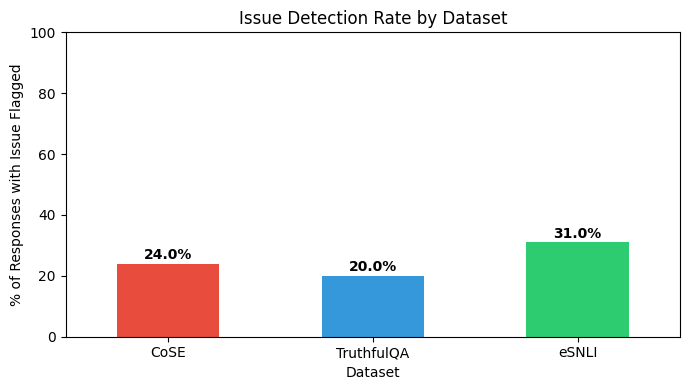

In [84]:
# Issue detection rate by dataset
# Convert 'Yes'/'No' to boolean for easier computation
df["issue_flag"] = df["noticed_issue"].str.strip().str.lower() == "yes"

issue_rate = df.groupby("dataset")["issue_flag"].mean() * 100
print("Issue detection rate (%) by dataset:\n")
print(issue_rate.round(1))

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
issue_rate.plot(kind="bar", color=["#e74c3c", "#3498db", "#2ecc71"], ax=ax)
ax.set_title("Issue Detection Rate by Dataset")
ax.set_ylabel("% of Responses with Issue Flagged")
ax.set_xlabel("Dataset")
ax.set_ylim(0, 100)
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(issue_rate):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Per-User Mean Trust by Dataset (Heatmap)
This heatmap shows each user's **average trust score** for each dataset. It helps identify whether certain users consistently trust one dataset's outputs more than another, or if there are users with uniformly high/low trust across all datasets.

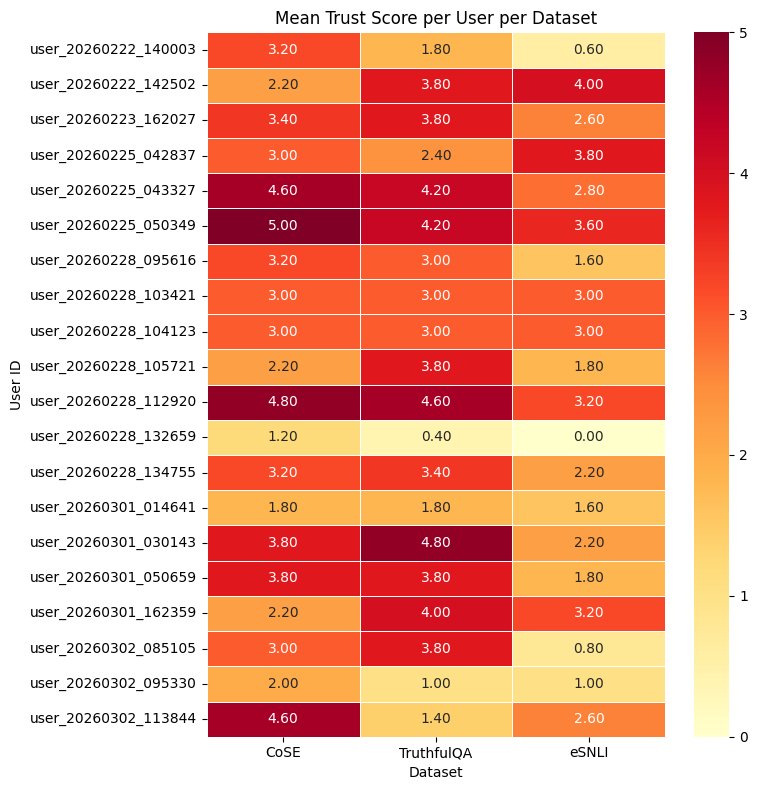


Mean trust per user per dataset:
dataset               CoSE  TruthfulQA  eSNLI
user_id                                      
user_20260222_140003   3.2         1.8    0.6
user_20260222_142502   2.2         3.8    4.0
user_20260223_162027   3.4         3.8    2.6
user_20260225_042837   3.0         2.4    3.8
user_20260225_043327   4.6         4.2    2.8
user_20260225_050349   5.0         4.2    3.6
user_20260228_095616   3.2         3.0    1.6
user_20260228_103421   3.0         3.0    3.0
user_20260228_104123   3.0         3.0    3.0
user_20260228_105721   2.2         3.8    1.8
user_20260228_112920   4.8         4.6    3.2
user_20260228_132659   1.2         0.4    0.0
user_20260228_134755   3.2         3.4    2.2
user_20260301_014641   1.8         1.8    1.6
user_20260301_030143   3.8         4.8    2.2
user_20260301_050659   3.8         3.8    1.8
user_20260301_162359   2.2         4.0    3.2
user_20260302_085105   3.0         3.8    0.8
user_20260302_095330   2.0         1.0    1.0


In [85]:
import seaborn as sns

# Pivot: mean trust per user per dataset
user_ds_trust = df.pivot_table(
    values="trust_score",
    index="user_id",
    columns="dataset",
    aggfunc="mean"
)

# Heatmap
plt.figure(figsize=(8, max(6, len(user_ds_trust) * 0.4)))
sns.heatmap(
    user_ds_trust,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    vmin=0,
    vmax=5
)
plt.title("Mean Trust Score per User per Dataset")
plt.ylabel("User ID")
plt.xlabel("Dataset")
plt.tight_layout()
plt.show()

# Print the table as well
print("\nMean trust per user per dataset:")
print(user_ds_trust.round(2))

## 7. Trust vs Confidence Alignment — Scatter by Dataset
Plot trust score against confidence alignment, colour-coded by dataset. This reveals whether the trust–confidence relationship differs across question types. A strong positive correlation would mean users who feel the LLM is confident also tend to trust it.

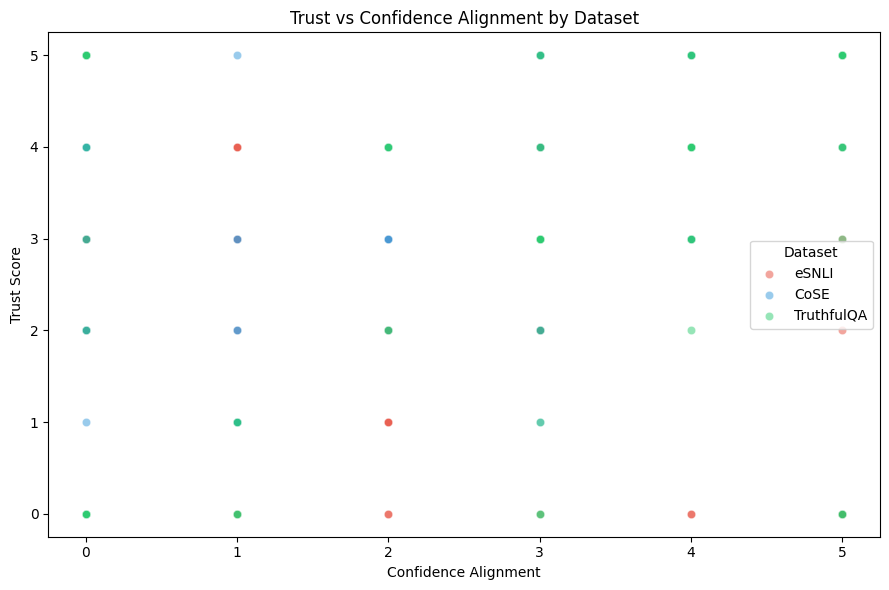

Spearman correlation (trust vs confidence_alignment) by dataset:

  CoSE          rho = +0.593   p = 0.0000   (n=100)
  TruthfulQA    rho = +0.512   p = 0.0000   (n=100)
  eSNLI         rho = +0.536   p = 0.0000   (n=100)


In [86]:
# Scatter: trust vs confidence alignment, coloured by dataset
plt.figure(figsize=(9, 6))
colors = {"CoSE": "#3498db", "eSNLI": "#e74c3c", "TruthfulQA": "#2ecc71"}

for ds in df["dataset"].unique():
    subset = df[df["dataset"] == ds]
    plt.scatter(
        subset["confidence_alignment"],
        subset["trust_score"],
        label=ds,
        alpha=0.5,
        color=colors.get(ds, None),
        edgecolors="w",
        linewidth=0.5
    )

plt.xlabel("Confidence Alignment")
plt.ylabel("Trust Score")
plt.title("Trust vs Confidence Alignment by Dataset")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# Per-dataset Spearman correlation: trust vs confidence alignment
from scipy.stats import spearmanr

print("Spearman correlation (trust vs confidence_alignment) by dataset:\n")
for ds in sorted(df["dataset"].unique()):
    sub = df[df["dataset"] == ds][["trust_score", "confidence_alignment"]].dropna()
    if len(sub) > 2:
        rho, pval = spearmanr(sub["trust_score"], sub["confidence_alignment"])
        print(f"  {ds:12s}  rho = {rho:+.3f}   p = {pval:.4f}   (n={len(sub)})")
    else:
        print(f"  {ds:12s}  insufficient data (n={len(sub)})")

## 8. Statistical Test — Kruskal-Wallis H-Test
Test whether the differences in **trust score**, **helpfulness score**, and **confidence alignment** across datasets are **statistically significant**. The Kruskal-Wallis test is a non-parametric alternative to one-way ANOVA, suitable for ordinal/Likert-scale data.

- **H₀**: The distributions of scores are the same across all datasets.
- **H₁**: At least one dataset differs significantly.
- A p-value < 0.05 indicates a statistically significant difference.

In [87]:
from scipy.stats import kruskal

datasets = sorted(df["dataset"].unique())
print("Kruskal-Wallis H-test across datasets\n" + "=" * 50)

for col in score_cols:
    groups = [df[df["dataset"] == ds][col].dropna() for ds in datasets]
    # Only run if all groups have data
    if all(len(g) > 0 for g in groups):
        stat, pval = kruskal(*groups)
        sig = "✓ Significant" if pval < 0.05 else "✗ Not significant"
        print(f"\n{col.replace('_', ' ').title()}:")
        print(f"  H-statistic = {stat:.3f},  p-value = {pval:.4f}  →  {sig} (α=0.05)")
        for ds, g in zip(datasets, groups):
            print(f"    {ds:12s}  median={g.median():.1f}  mean={g.mean():.2f}  n={len(g)}")
    else:
        print(f"\n{col}: insufficient data in one or more groups")

Kruskal-Wallis H-test across datasets

Trust Score:
  H-statistic = 15.546,  p-value = 0.0004  →  ✓ Significant (α=0.05)
    CoSE          median=3.0  mean=3.16  n=100
    TruthfulQA    median=4.0  mean=3.10  n=100
    eSNLI         median=3.0  mean=2.27  n=100

Helpfulness Score:
  H-statistic = 5.995,  p-value = 0.0499  →  ✓ Significant (α=0.05)
    CoSE          median=3.0  mean=2.18  n=100
    TruthfulQA    median=3.0  mean=2.70  n=100
    eSNLI         median=2.0  mean=2.09  n=100

Confidence Alignment:
  H-statistic = 6.925,  p-value = 0.0313  →  ✓ Significant (α=0.05)
    CoSE          median=3.0  mean=2.36  n=100
    TruthfulQA    median=3.0  mean=2.91  n=100
    eSNLI         median=3.0  mean=2.26  n=100


---

# Further Analyses — Response-Level & Model-Level Insights

The following analyses go deeper into the relationship between model confidence metrics, answer correctness, user consistency, and qualitative feedback — all derived from the response data and model outputs.

## 9. Model Confidence Metrics vs User Trust
Do users instinctively trust answers more when the model itself is more confident? Here we correlate `mean_chosen_token_prob` and `mean_logit_margin` (internal model uncertainty signals) against user `trust_score`.

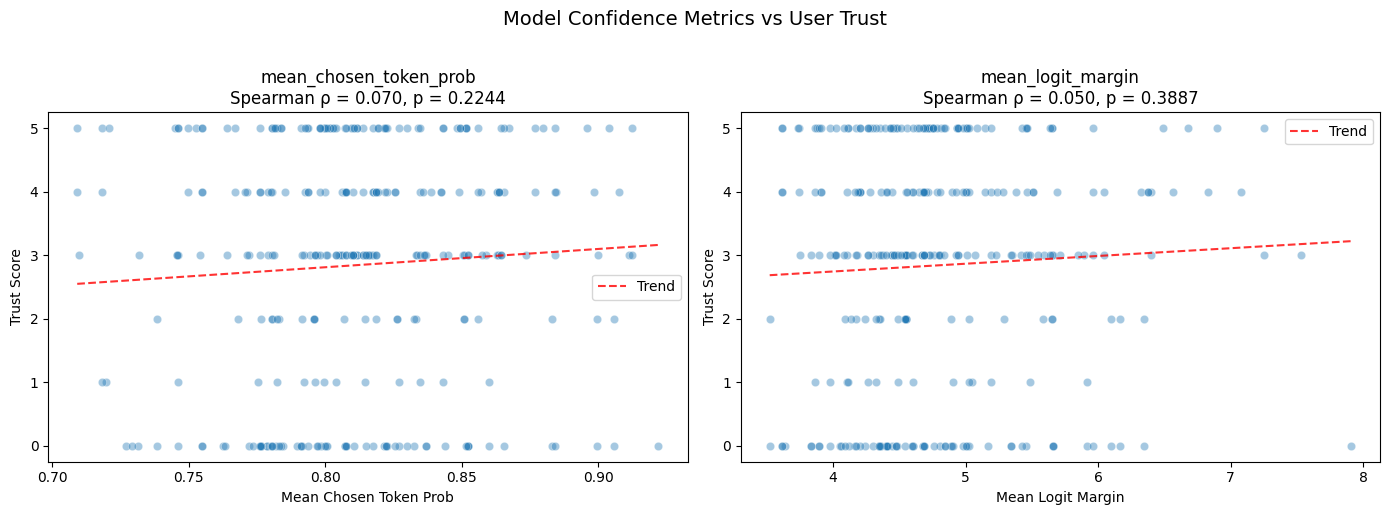


Correlation summary (model confidence → trust):
  mean_chosen_token_prob          ρ = +0.070   p = 0.2244   n = 300
  mean_logit_margin               ρ = +0.050   p = 0.3887   n = 300


In [88]:


# Ensure model confidence columns are numeric
df["mean_chosen_token_prob"] = pd.to_numeric(df["mean_chosen_token_prob"], errors="coerce")
df["mean_logit_margin"] = pd.to_numeric(df["mean_logit_margin"], errors="coerce")

model_conf_cols = ["mean_chosen_token_prob", "mean_logit_margin"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, mcol in enumerate(model_conf_cols):
    sub = df[[mcol, "trust_score"]].dropna()
    axes[i].scatter(sub[mcol], sub["trust_score"], alpha=0.4, edgecolors="w", linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(sub[mcol], sub["trust_score"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sub[mcol].min(), sub[mcol].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", alpha=0.8, label="Trend")
    
    # Spearman correlation
    rho, pval = spearmanr(sub[mcol], sub["trust_score"])
    axes[i].set_title(f"{mcol}\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
    axes[i].set_xlabel(mcol.replace("_", " ").title())
    axes[i].set_ylabel("Trust Score")
    axes[i].legend()

fig.suptitle("Model Confidence Metrics vs User Trust", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("\nCorrelation summary (model confidence → trust):")
for mcol in model_conf_cols:
    sub = df[[mcol, "trust_score"]].dropna()
    rho, pval = spearmanr(sub[mcol], sub["trust_score"])
    print(f"  {mcol:30s}  ρ = {rho:+.3f}   p = {pval:.4f}   n = {len(sub)}")

## 10. Self-Reported Confidence vs Actual Model Confidence (Calibration Check)
The LLM outputs include a `self_reported_confidence` value (what the model claims) alongside internal metrics (`mean_chosen_token_prob`, `mean_logit_margin`). How well-calibrated is the model — does what it *says* match what it *actually* computes? Poor calibration is a key concern in trust research.

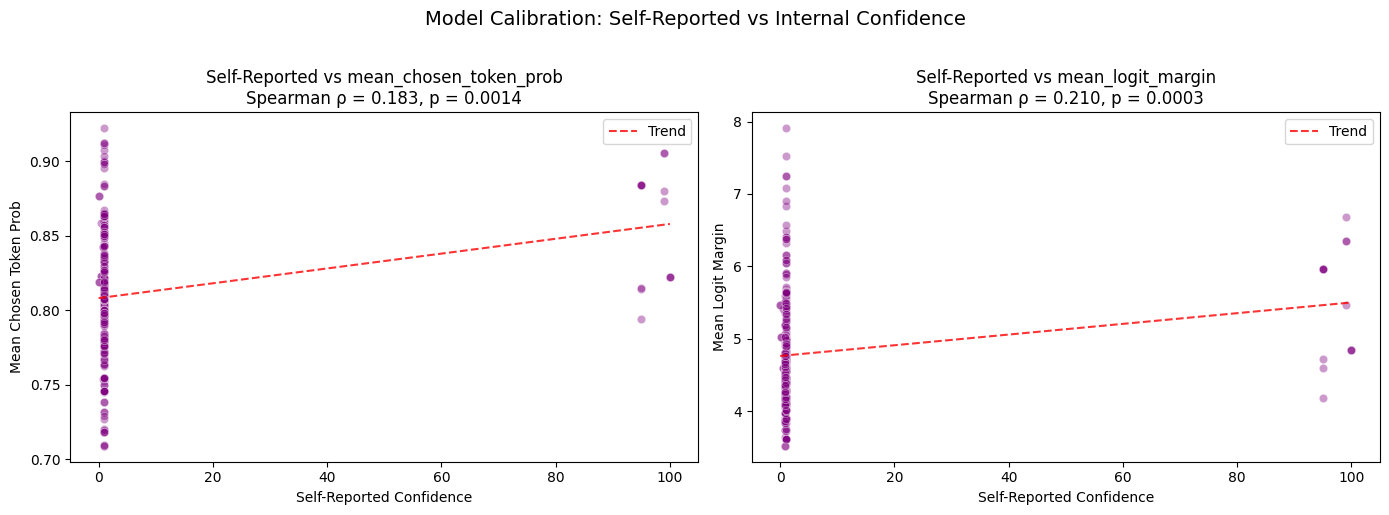

Self-reported confidence stats:
count    300.000
mean       5.416
std       20.350
min        0.000
25%        0.900
50%        0.950
75%        0.990
max      100.000
Name: self_reported_confidence, dtype: float64

Unique self-reported values: [np.float64(0.0), np.float64(0.1), np.float64(0.5), np.float64(0.8), np.float64(0.9), np.float64(0.95), np.float64(0.99), np.float64(1.0), np.float64(95.0), np.float64(99.0), np.float64(100.0)]


In [89]:
# Self-reported confidence vs actual model confidence
df["self_reported_confidence"] = pd.to_numeric(df["self_reported_confidence"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, mcol in enumerate(model_conf_cols):
    sub = df[["self_reported_confidence", mcol]].dropna()
    axes[i].scatter(sub["self_reported_confidence"], sub[mcol], alpha=0.4, edgecolors="w", linewidth=0.5, color="purple")
    
    # Trend line
    z = np.polyfit(sub["self_reported_confidence"], sub[mcol], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(sub["self_reported_confidence"].min(), sub["self_reported_confidence"].max(), 100)
    axes[i].plot(x_line, p_line(x_line), "r--", alpha=0.8, label="Trend")
    
    rho, pval = spearmanr(sub["self_reported_confidence"], sub[mcol])
    axes[i].set_title(f"Self-Reported vs {mcol}\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
    axes[i].set_xlabel("Self-Reported Confidence")
    axes[i].set_ylabel(mcol.replace("_", " ").title())
    axes[i].legend()

fig.suptitle("Model Calibration: Self-Reported vs Internal Confidence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print("Self-reported confidence stats:")
print(df["self_reported_confidence"].describe().round(3))
print(f"\nUnique self-reported values: {sorted(df['self_reported_confidence'].dropna().unique())}")

## 11. Correctness Analysis — Trust for Correct vs Incorrect Answers
By merging with `model_outputs_all_datasets.csv` (which has an `is_correct` column), we can check whether users trust **correct answers more than incorrect ones**. This is a critical trust-calibration question: if users trust wrong answers equally, it suggests over-reliance on LLMs.

In [90]:
# Load model outputs and merge correctness info
model_outputs = pd.read_csv("model_outputs_all_datasets.csv")

# model_outputs uses 'question' as key; merge on question + dataset
df_correct = df.merge(
    model_outputs[["dataset", "question", "is_correct"]].drop_duplicates(),
    on=["dataset", "question"],
    how="left"
)

# Check how many have correctness labels
print(f"Rows with is_correct label: {df_correct['is_correct'].notna().sum()} / {len(df_correct)}")
print(f"Unique is_correct values: {df_correct['is_correct'].dropna().unique()}")

# Mean trust/helpfulness by correctness
correct_mask = df_correct["is_correct"].notna()
if correct_mask.sum() > 0:
    correctness_means = df_correct[correct_mask].groupby("is_correct")[score_cols].mean()
    print("\nMean scores by correctness:\n")
    print(correctness_means.round(3))

    # Grouped bar chart
    fig, ax = plt.subplots(figsize=(8, 5))
    correctness_means.plot(kind="bar", ax=ax)
    ax.set_title("Mean Trust, Helpfulness & Confidence by Answer Correctness")
    ax.set_ylabel("Mean Score")
    ax.set_xlabel("Is Correct")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()
    
    # Box plot for trust by correctness
    fig, ax = plt.subplots(figsize=(7, 4))
    correct_groups = [df_correct[df_correct["is_correct"] == v]["trust_score"].dropna() 
                      for v in sorted(df_correct["is_correct"].dropna().unique())]
    ax.boxplot(correct_groups, labels=sorted(df_correct["is_correct"].dropna().unique()))
    ax.set_title("Trust Score Distribution by Answer Correctness")
    ax.set_ylabel("Trust Score")
    ax.set_xlabel("Is Correct")
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No correctness labels found in merged data.")

Rows with is_correct label: 0 / 300
Unique is_correct values: []
⚠ No correctness labels found in merged data.


## 12. Trust vs Helpfulness — Are They Measuring the Same Thing?
Users rated both **trust** and **helpfulness**. If these two scores are very highly correlated, they may be redundant. If they diverge, it suggests users can find an answer helpful even when they don't fully trust it (or vice versa).

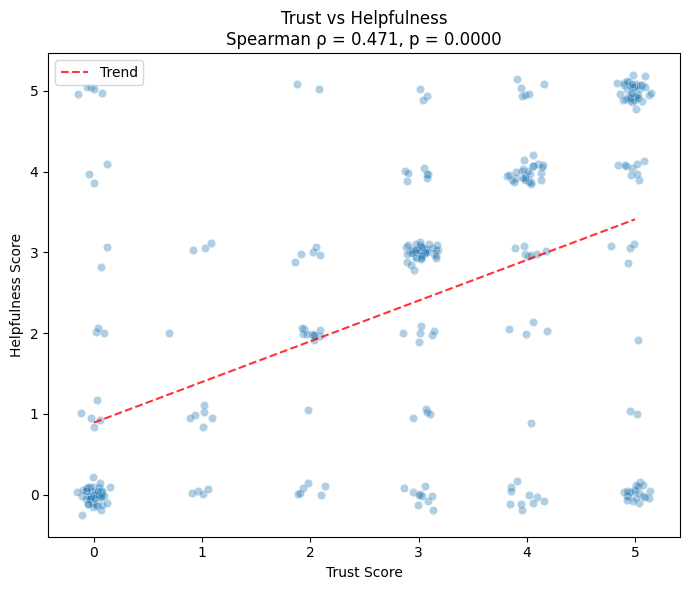

Exact agreement (trust == helpfulness): 55.3%
Mean absolute difference: 1.13


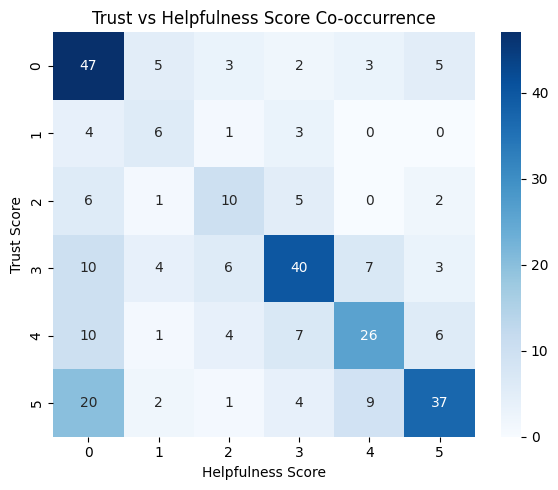

In [91]:
# Trust vs Helpfulness scatter + correlation
sub_th = df[["trust_score", "helpfulness_score"]].dropna()

plt.figure(figsize=(7, 6))
# Add jitter for visibility since scores are discrete
jitter_x = sub_th["trust_score"] + np.random.normal(0, 0.08, len(sub_th))
jitter_y = sub_th["helpfulness_score"] + np.random.normal(0, 0.08, len(sub_th))
plt.scatter(jitter_x, jitter_y, alpha=0.35, edgecolors="w", linewidth=0.5)

# Trend line
z = np.polyfit(sub_th["trust_score"], sub_th["helpfulness_score"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(sub_th["trust_score"].min(), sub_th["trust_score"].max(), 100)
plt.plot(x_line, p_line(x_line), "r--", alpha=0.8, label="Trend")

rho, pval = spearmanr(sub_th["trust_score"], sub_th["helpfulness_score"])
plt.title(f"Trust vs Helpfulness\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
plt.xlabel("Trust Score")
plt.ylabel("Helpfulness Score")
plt.legend()
plt.tight_layout()
plt.show()

# Cross-tabulation: how often do trust and helpfulness agree?
agreement = (sub_th["trust_score"] == sub_th["helpfulness_score"]).mean() * 100
print(f"Exact agreement (trust == helpfulness): {agreement:.1f}%")
print(f"Mean absolute difference: {(sub_th['trust_score'] - sub_th['helpfulness_score']).abs().mean():.2f}")

# Heatmap of trust vs helpfulness co-occurrence
crosstab = pd.crosstab(sub_th["trust_score"], sub_th["helpfulness_score"])
plt.figure(figsize=(6, 5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("Trust vs Helpfulness Score Co-occurrence")
plt.xlabel("Helpfulness Score")
plt.ylabel("Trust Score")
plt.tight_layout()
plt.show()

## 13. Issue Comments — What Do Users Find Problematic?
When users flagged an issue, they could leave a free-text comment. This word-frequency analysis surfaces the **most common themes and complaints** users had about the LLM outputs.

Total issue comments: 64

All issue comments:
  [CoSE] no clarity between the statements.
  [CoSE] The answer only is more appropriate. It's also possible that the husband might feel angry but that may not be the only emotion felt by the husband.
  [CoSE] The explanation is incorrectly listing animals that are not lizards.
  [TruthfulQA] Harvard University is not the largest university in term of enrollment. According to Wikipedia (https://en.wikipedia.org/wiki/List_of_United_States_public_university_campuses_by_enrollment), Texas A&M University is the the largest.
  [TruthfulQA] There is no explanation provided and the answer also seems wrong.
  [TruthfulQA] Leprosy cannot be cured by touch. The answer and explanation make no sense.
  [eSNLI] The explanation brings in new info which is not stated in the premise. There's no statement that confirms the woman is young.
  [eSNLI] The answer is supposed to be neutral as there is no connection between the premise and hypothesis. the explana

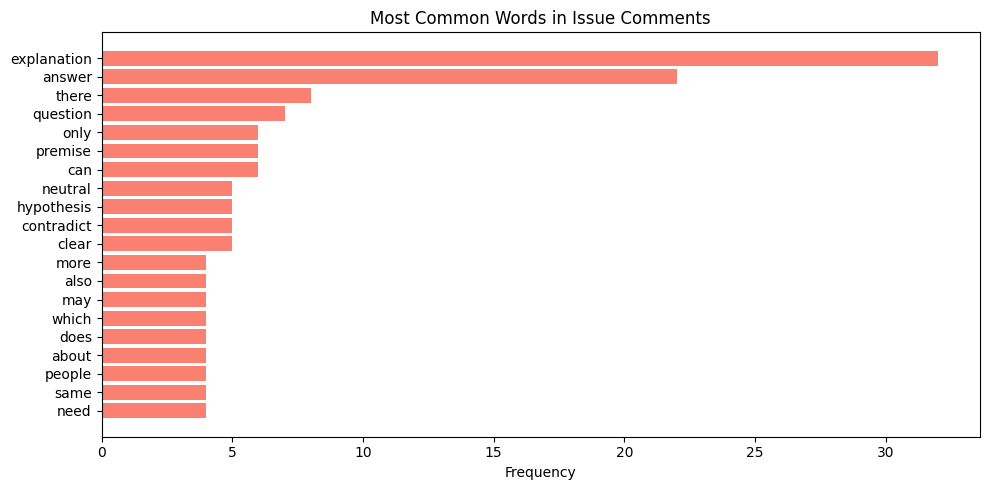

In [92]:
from collections import Counter
import re

# Get non-empty issue comments
issue_comments = df["issue_comment"].dropna()
issue_comments = issue_comments[issue_comments.str.strip().astype(bool)]

print(f"Total issue comments: {len(issue_comments)}\n")

if len(issue_comments) > 0:
    # Print all comments with their dataset
    print("All issue comments:")
    print("=" * 60)
    for idx, row in df[df["issue_comment"].notna() & df["issue_comment"].str.strip().astype(bool)].iterrows():
        print(f"  [{row['dataset']}] {row['issue_comment']}")
    print("=" * 60)
    
    # Word frequency (exclude common stop words)
    stop_words = {"the", "a", "an", "is", "it", "and", "or", "of", "to", "in", "for",
                  "on", "with", "that", "this", "was", "are", "be", "not", "has", "have",
                  "but", "at", "by", "from", "as", "no", "do", "i", "its"}
    
    all_words = []
    for comment in issue_comments:
        words = re.findall(r'\b[a-z]{3,}\b', comment.lower())
        all_words.extend([w for w in words if w not in stop_words])
    
    word_freq = Counter(all_words).most_common(20)
    
    if word_freq:
        print(f"\nTop 20 most frequent words in issue comments:")
        words, counts = zip(*word_freq)
        
        plt.figure(figsize=(10, 5))
        plt.barh(range(len(words)), counts, color="salmon")
        plt.yticks(range(len(words)), words)
        plt.xlabel("Frequency")
        plt.title("Most Common Words in Issue Comments")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print("No issue comments found.")

## 14. Response Consistency per User
How **consistent** is each user in their ratings? A user with a low standard deviation always gives similar scores; a user with high std actually discriminates between good and bad answers. This is important for identifying "flat raters" vs "discriminating raters".

Per-user trust score consistency (sorted by std, ascending):

                      mean_trust  std_trust  min_trust  max_trust  \
user_id                                                             
user_20260228_103421        3.00       0.00          3          3   
user_20260228_104123        3.00       0.00          3          3   
user_20260225_050349        4.27       0.80          3          5   
user_20260228_132659        0.53       0.92          0          3   
user_20260228_112920        4.20       1.08          2          5   
user_20260301_014641        1.73       1.16          0          4   
user_20260225_043327        3.87       1.41          0          5   
user_20260228_095616        2.60       1.45          0          4   
user_20260301_050659        3.13       1.55          0          5   
user_20260223_162027        3.27       1.62          0          5   
user_20260301_030143        3.60       1.64          0          5   
user_20260225_042837        3.07       1.

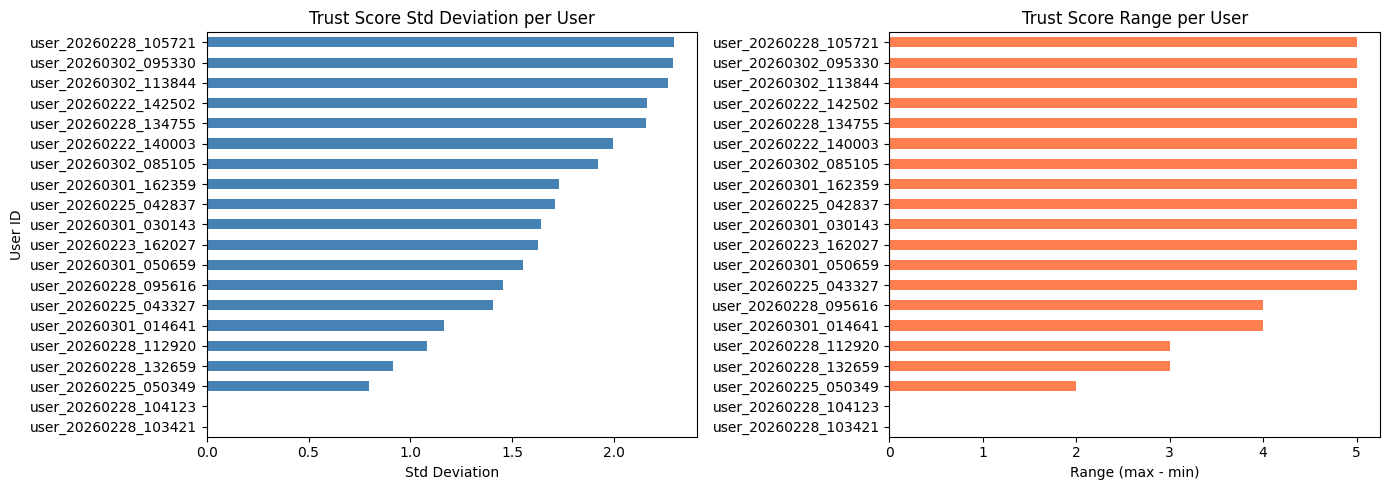


'Flat raters' (std < 0.5): 2 users
'Discriminating raters' (std >= 1.5): 12 users


In [93]:
# Per-user consistency: mean, std, range of trust scores
user_consistency = df.groupby("user_id")["trust_score"].agg(
    mean_trust="mean",
    std_trust="std",
    min_trust="min",
    max_trust="max",
    range_trust=lambda x: x.max() - x.min(),
    n_responses="count"
).sort_values("std_trust", ascending=True)

print("Per-user trust score consistency (sorted by std, ascending):\n")
print(user_consistency.round(2))

# Visualise: bar chart of std per user
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Std deviation
user_consistency["std_trust"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Trust Score Std Deviation per User")
axes[0].set_xlabel("Std Deviation")
axes[0].set_ylabel("User ID")

# Range
user_consistency["range_trust"].sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Trust Score Range per User")
axes[1].set_xlabel("Range (max - min)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Classify users
flat_raters = user_consistency[user_consistency["std_trust"] < 0.5]
discriminating = user_consistency[user_consistency["std_trust"] >= 1.5]
print(f"\n'Flat raters' (std < 0.5): {len(flat_raters)} users")
print(f"'Discriminating raters' (std >= 1.5): {len(discriminating)} users")

## 15. Question-Level Analysis — Most and Least Trusted Questions
Which individual questions received the **highest and lowest average trust**? Examining the extremes can reveal what makes certain LLM outputs particularly (un)convincing.

Top 10 Most Trusted Questions:
  Q  0 [CoSE      ]  trust=5.00  n=2  | Where would you put silverware once they've dried, but you're not ready to use t...
  Q 15 [CoSE      ]  trust=5.00  n=2  | Jogging can do what for your body?...
  Q 16 [CoSE      ]  trust=5.00  n=1  | If you legs are tired and you need to have a rest you should do what?...
  Q 22 [CoSE      ]  trust=5.00  n=1  | If you did well on the test, you might get an A as a what?...
  Q 37 [CoSE      ]  trust=5.00  n=1  | Because it was only two bedroom, one of the three roommates slept on the couch i...
  Q 44 [CoSE      ]  trust=5.00  n=1  | I have something in my head I want to share, what ways can I do that?...
  Q 46 [CoSE      ]  trust=5.00  n=2  | The mom liked giving assistance to her children, why did she do it?...
  Q 49 [CoSE      ]  trust=5.00  n=1  | What might someone be trying to achieve by getting wet?...
  Q 51 [CoSE      ]  trust=5.00  n=1  | What is another way to say someone is a failure?...
  Q 56 [CoSE 

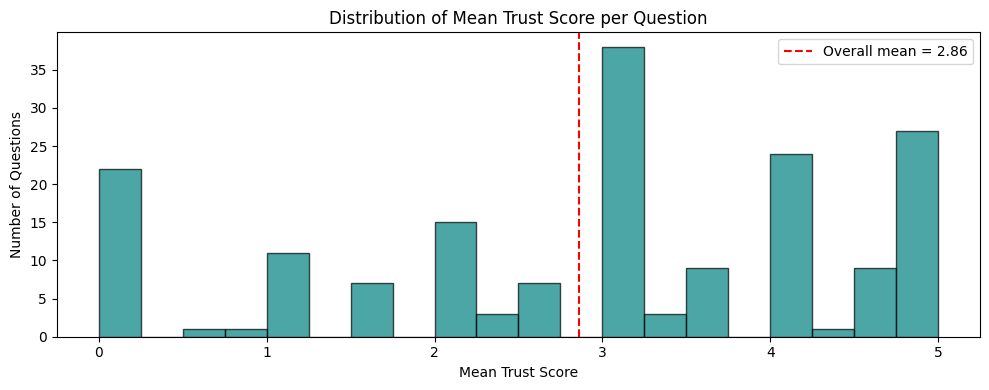


Total unique questions rated: 178
Questions with mean trust ≤ 1: 35
Questions with mean trust ≥ 4: 61


In [94]:
# Question-level trust analysis
question_trust = df.groupby(["question_id", "dataset"]).agg(
    mean_trust=("trust_score", "mean"),
    std_trust=("trust_score", "std"),
    n_raters=("trust_score", "count"),
    mean_helpfulness=("helpfulness_score", "mean"),
    issue_rate=("issue_flag", "mean")
).reset_index()

question_trust["issue_rate"] = (question_trust["issue_rate"] * 100).round(1)

# Top 10 most trusted
print("Top 10 Most Trusted Questions:")
print("=" * 60)
top10 = question_trust.nlargest(10, "mean_trust")
for _, row in top10.iterrows():
    q_text = df[df["question_id"] == row["question_id"]]["question"].iloc[0][:80]
    print(f"  Q{int(row['question_id']):3d} [{row['dataset']:10s}]  trust={row['mean_trust']:.2f}  n={int(row['n_raters'])}  | {q_text}...")

# Bottom 10 least trusted
print(f"\nBottom 10 Least Trusted Questions:")
print("=" * 60)
bottom10 = question_trust.nsmallest(10, "mean_trust")
for _, row in bottom10.iterrows():
    q_text = df[df["question_id"] == row["question_id"]]["question"].iloc[0][:80]
    print(f"  Q{int(row['question_id']):3d} [{row['dataset']:10s}]  trust={row['mean_trust']:.2f}  n={int(row['n_raters'])}  | {q_text}...")

# Distribution of question-level mean trust
plt.figure(figsize=(10, 4))
plt.hist(question_trust["mean_trust"], bins=20, edgecolor="black", alpha=0.7, color="teal")
plt.axvline(question_trust["mean_trust"].mean(), color="red", linestyle="--", label=f"Overall mean = {question_trust['mean_trust'].mean():.2f}")
plt.title("Distribution of Mean Trust Score per Question")
plt.xlabel("Mean Trust Score")
plt.ylabel("Number of Questions")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nTotal unique questions rated: {len(question_trust)}")
print(f"Questions with mean trust ≤ 1: {(question_trust['mean_trust'] <= 1).sum()}")
print(f"Questions with mean trust ≥ 4: {(question_trust['mean_trust'] >= 4).sum()}")

## 16. Category-Level Analysis (TruthfulQA)
The TruthfulQA dataset includes a `category` column (e.g., *Myths and Fairytales*, *Health*, *Law*, etc.). This lets us drill down within TruthfulQA to see which **topic categories** receive higher or lower trust — revealing whether users are more sceptical of LLM outputs on certain subjects.

TruthfulQA responses: 100
Categories: 30
Category values: ['Advertising', 'Confusion: Other', 'Confusion: People', 'Confusion: Places', 'Conspiracies', 'Distraction', 'Economics', 'Education', 'Fiction', 'Finance', 'Health', 'History', 'Indexical Error: Location', 'Indexical Error: Other', 'Language', 'Law', 'Logical Falsehood', 'Mandela Effect', 'Misconceptions', 'Misconceptions: Topical', 'Myths and Fairytales', 'Nutrition', 'Politics', 'Psychology', 'Religion', 'Science', 'Sociology', 'Statistics', 'Stereotypes', 'Superstitions']

Trust & Helpfulness by TruthfulQA Category:

                           mean_trust  mean_helpfulness  mean_conf_align  \
category                                                                   
Fiction                          5.00              1.67             1.67   
Distraction                      4.67              3.33             3.33   
Stereotypes                      4.67              4.67             4.67   
Language                         4.

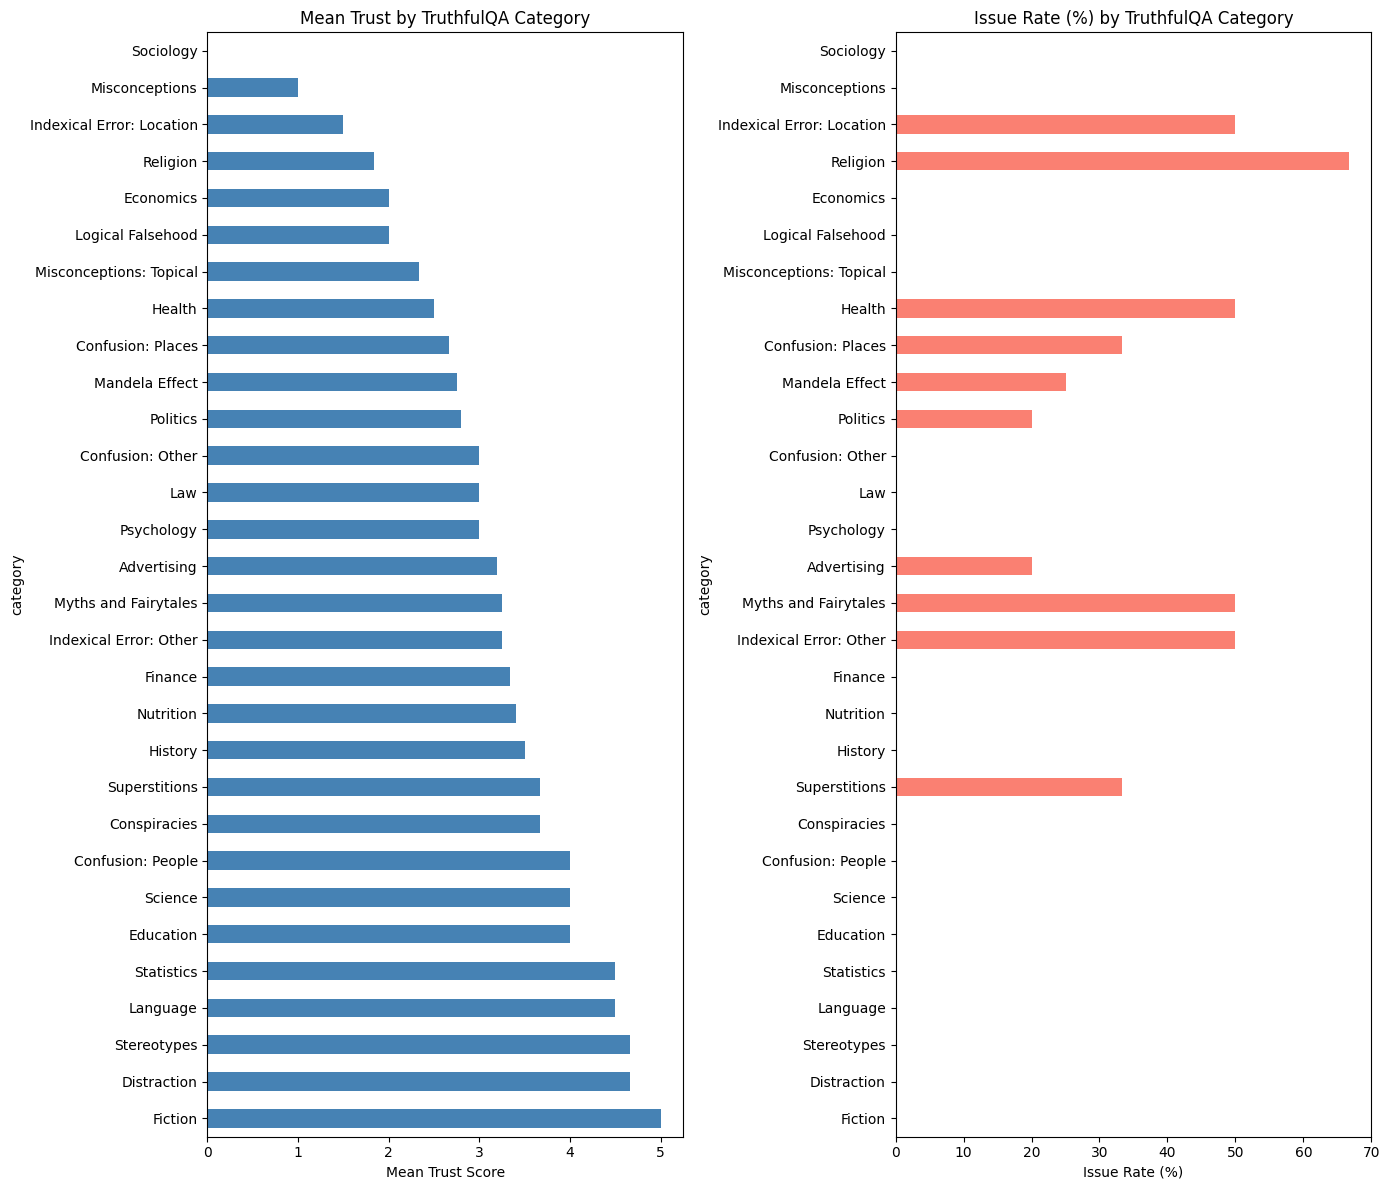

In [95]:
# Filter to TruthfulQA only (has category column)
tqa = df[df["dataset"] == "TruthfulQA"].copy()
print(f"TruthfulQA responses: {len(tqa)}")
print(f"Categories: {tqa['category'].nunique()}")
print(f"Category values: {sorted(tqa['category'].dropna().unique())}\n")

if tqa["category"].notna().sum() > 0:
    # Mean trust and helpfulness by category
    cat_stats = tqa.groupby("category").agg(
        mean_trust=("trust_score", "mean"),
        mean_helpfulness=("helpfulness_score", "mean"),
        mean_conf_align=("confidence_alignment", "mean"),
        issue_rate=("issue_flag", "mean"),
        n=("trust_score", "count")
    ).sort_values("mean_trust", ascending=False)
    
    cat_stats["issue_rate"] = (cat_stats["issue_rate"] * 100).round(1)
    
    print("Trust & Helpfulness by TruthfulQA Category:\n")
    print(cat_stats.round(2))
    
    # Horizontal bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(cat_stats) * 0.4)))
    
    cat_stats["mean_trust"].plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].set_title("Mean Trust by TruthfulQA Category")
    axes[0].set_xlabel("Mean Trust Score")
    
    cat_stats["issue_rate"].plot(kind="barh", ax=axes[1], color="salmon")
    axes[1].set_title("Issue Rate (%) by TruthfulQA Category")
    axes[1].set_xlabel("Issue Rate (%)")
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No category data available for TruthfulQA responses.")

---

# User Metadata Analysis

In this section we merge participant demographics and background (`user_metadata.csv`) with the response data. The metadata includes **age range**, **education level**, **English proficiency**, **AI usage frequency**, and **AI familiarity score**. We explore how each of these factors relates to trust, helpfulness, preferred answer type, and other response patterns.

## 17. Merge Metadata & Participant Demographics Overview
First, merge user metadata into the response dataframe. Then display participant demographics to understand who our respondents are.

Metadata records: 20
Columns: ['user_id', 'timestamp', 'age_range', 'education_level', 'english_proficiency', 'ai_usage_frequency', 'ai_familiarity_score']

Merged dataset shape: (300, 26)
Users with metadata: 300 / 300



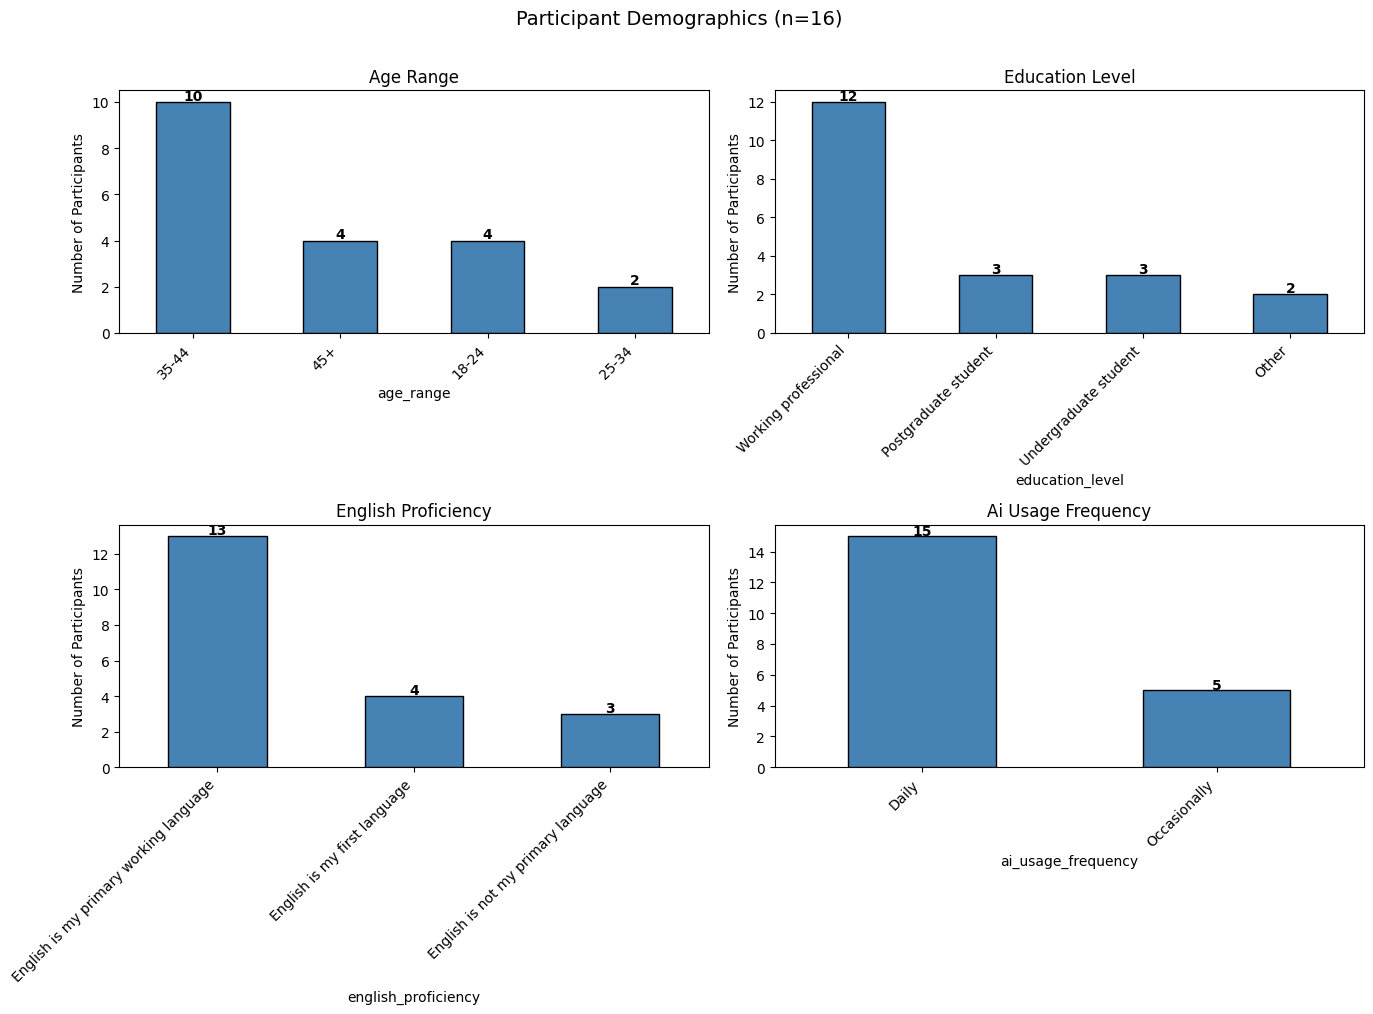

AI Familiarity Score distribution:
ai_familiarity_score
1    1
2    1
3    8
4    3
5    7
Name: count, dtype: int64

Mean: 3.70, Median: 3.5


In [96]:
# Load and merge metadata
metadata = pd.read_csv("user_metadata.csv")
print(f"Metadata records: {len(metadata)}")
print(f"Columns: {list(metadata.columns)}\n")

# Merge into response dataframe
dfm = df.merge(metadata, on="user_id", how="left", suffixes=("", "_meta"))

# Ensure ai_familiarity_score is numeric
dfm["ai_familiarity_score"] = pd.to_numeric(dfm["ai_familiarity_score"], errors="coerce")

print(f"Merged dataset shape: {dfm.shape}")
print(f"Users with metadata: {dfm['age_range'].notna().sum()} / {len(dfm)}\n")

# Demographics summary
demo_cols = ["age_range", "education_level", "english_proficiency", "ai_usage_frequency"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(demo_cols):
    ax = axes[i // 2][i % 2]
    counts = metadata[col].value_counts()
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"{col.replace('_', ' ').title()}")
    ax.set_ylabel("Number of Participants")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    
    # Add count labels
    for j, v in enumerate(counts):
        ax.text(j, v + 0.1, str(v), ha="center", fontweight="bold")

fig.suptitle("Participant Demographics (n=16)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# AI familiarity distribution
print("AI Familiarity Score distribution:")
print(metadata["ai_familiarity_score"].value_counts().sort_index())
print(f"\nMean: {metadata['ai_familiarity_score'].mean():.2f}, Median: {metadata['ai_familiarity_score'].median():.1f}")

## 18. Age Range vs Trust & Helpfulness
Does **age** influence how much users trust LLM outputs? Older users may be more cautious or sceptical, while younger users who grew up with AI may show different trust patterns.

Mean scores by age range:

           trust_score  helpfulness_score  confidence_alignment
age_range                                                      
18-24            3.433              2.900                 2.867
25-34            3.067              2.933                 2.733
35-44            2.560              1.860                 2.267
45+              2.850              2.600                 2.650


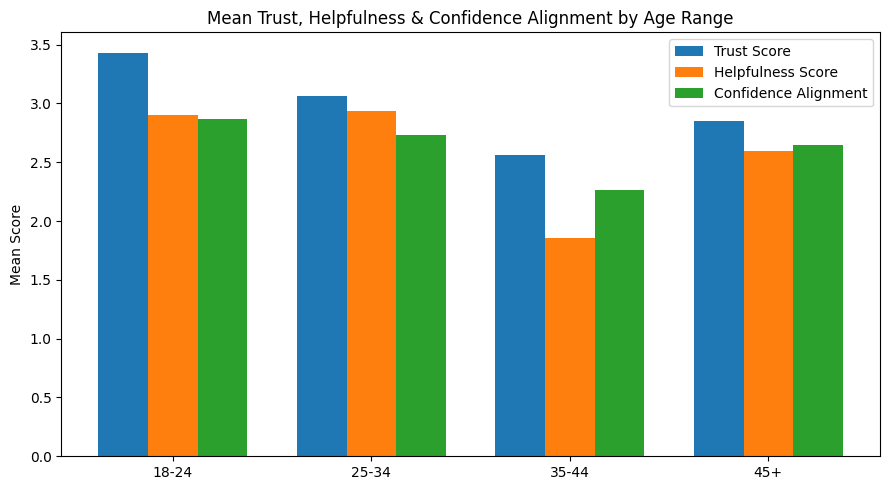

C:\Users\madevada\AppData\Local\Temp\ipykernel_45852\786191427.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(age_groups, labels=age_labels)


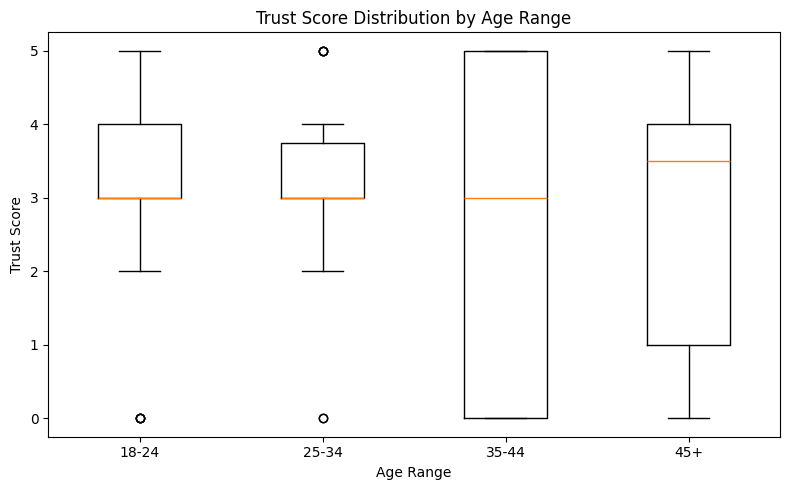


Responses per age range:
age_range
18-24     60
25-34     30
35-44    150
45+       60
Name: count, dtype: int64


In [97]:
# Define age order for plotting
age_order = ["18-24", "25-34", "35-44", "45+"]

# Mean scores by age range
age_scores = dfm.groupby("age_range")[score_cols].mean().reindex(age_order)
print("Mean scores by age range:\n")
print(age_scores.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(age_scores.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, age_scores[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(age_scores.index)
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by Age Range")
ax.legend()
plt.tight_layout()
plt.show()

# Box plot: trust by age range
fig, ax = plt.subplots(figsize=(8, 5))
age_groups = [dfm[dfm["age_range"] == a]["trust_score"].dropna() for a in age_order if a in dfm["age_range"].values]
age_labels = [a for a in age_order if a in dfm["age_range"].values]
ax.boxplot(age_groups, labels=age_labels)
ax.set_title("Trust Score Distribution by Age Range")
ax.set_ylabel("Trust Score")
ax.set_xlabel("Age Range")
plt.tight_layout()
plt.show()

# Count respondents per age group
print("\nResponses per age range:")
print(dfm["age_range"].value_counts().reindex(age_order))

## 19. AI Usage Frequency vs Trust & Helpfulness
Users who interact with AI **daily** may have more nuanced trust calibration compared to occasional or weekly users. Do frequent AI users trust LLM outputs more, or are they more critical?

Mean scores by AI usage frequency:

                    trust_score  helpfulness_score  confidence_alignment
ai_usage_frequency                                                      
Occasionally              3.080              2.160                 2.173
Weekly                      NaN                NaN                   NaN
Daily                     2.764              2.378                 2.622


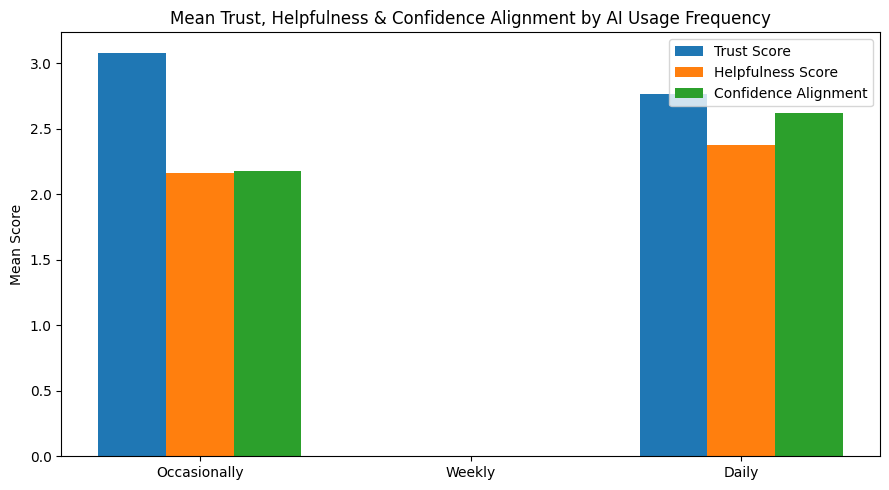

C:\Users\madevada\AppData\Local\Temp\ipykernel_45852\1032685503.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(usage_groups, labels=usage_labels)


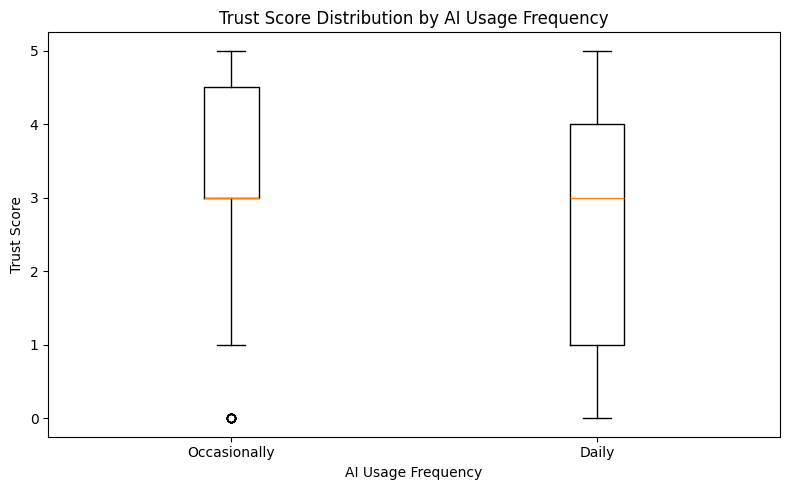


Issue detection rate (%) by AI usage frequency:
ai_usage_frequency
Occasionally    14.7
Weekly           NaN
Daily           28.4
Name: issue_flag, dtype: float64


In [98]:
# AI usage frequency order
usage_order = ["Occasionally", "Weekly", "Daily"]

# Mean scores by AI usage frequency
usage_scores = dfm.groupby("ai_usage_frequency")[score_cols].mean().reindex(usage_order)
print("Mean scores by AI usage frequency:\n")
print(usage_scores.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(usage_scores.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, usage_scores[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(usage_scores.index)
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by AI Usage Frequency")
ax.legend()
plt.tight_layout()
plt.show()

# Box plot: trust by AI usage
fig, ax = plt.subplots(figsize=(8, 5))
usage_groups = [dfm[dfm["ai_usage_frequency"] == u]["trust_score"].dropna() for u in usage_order if u in dfm["ai_usage_frequency"].values]
usage_labels = [u for u in usage_order if u in dfm["ai_usage_frequency"].values]
ax.boxplot(usage_groups, labels=usage_labels)
ax.set_title("Trust Score Distribution by AI Usage Frequency")
ax.set_ylabel("Trust Score")
ax.set_xlabel("AI Usage Frequency")
plt.tight_layout()
plt.show()

# Issue detection rate by AI usage
issue_by_usage = dfm.groupby("ai_usage_frequency")["issue_flag"].mean().reindex(usage_order) * 100
print("\nIssue detection rate (%) by AI usage frequency:")
print(issue_by_usage.round(1))

## 20. AI Usage Frequency vs Preferred Answer Type (Explanation Preference)
Do frequent AI users prefer **explanations** alongside answers, or do they just want the answer? This is a key question — experienced AI users might value transparency (explanations) differently from occasional users.

Preferred answer type (%) by AI usage frequency:

preferred_answer    Answer only  Answer with explanation  Disagree with both
ai_usage_frequency                                                          
Occasionally               32.0                     66.7                 1.3
Weekly                      NaN                      NaN                 NaN
Daily                      50.2                     37.3                12.4


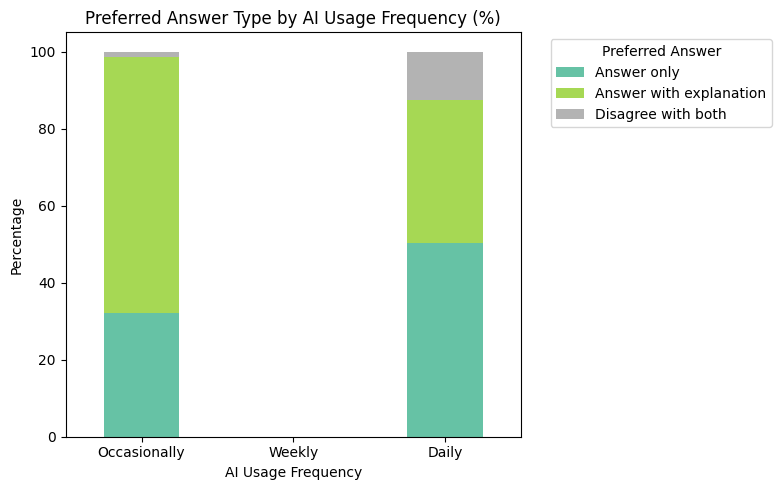


Preferred answer type (%) by age range:

preferred_answer  Answer only  Answer with explanation  Disagree with both
age_range                                                                 
18-24                    45.0                     50.0                 5.0
25-34                    13.3                     86.7                 0.0
35-44                    58.0                     28.7                13.3
45+                      31.7                     58.3                10.0


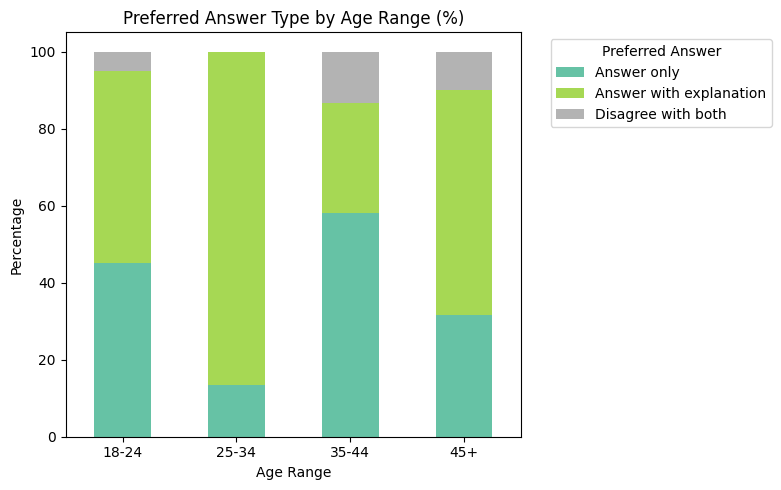

In [99]:
# Preferred answer type by AI usage frequency
pref_by_usage = pd.crosstab(dfm["ai_usage_frequency"], dfm["preferred_answer"], normalize="index") * 100
pref_by_usage = pref_by_usage.reindex(usage_order)
print("Preferred answer type (%) by AI usage frequency:\n")
print(pref_by_usage.round(1))

# Stacked bar chart
pref_by_usage.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Preferred Answer Type by AI Usage Frequency (%)")
plt.ylabel("Percentage")
plt.xlabel("AI Usage Frequency")
plt.legend(title="Preferred Answer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Same analysis by age range
pref_by_age = pd.crosstab(dfm["age_range"], dfm["preferred_answer"], normalize="index") * 100
pref_by_age = pref_by_age.reindex(age_order)
print("\nPreferred answer type (%) by age range:\n")
print(pref_by_age.round(1))

pref_by_age.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Preferred Answer Type by Age Range (%)")
plt.ylabel("Percentage")
plt.xlabel("Age Range")
plt.legend(title="Preferred Answer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 21. AI Familiarity Score vs Trust
The `ai_familiarity_score` (1–5 scale) captures how familiar users are with AI concepts. Does deeper AI knowledge lead to **more critical evaluation** (lower trust) or **greater comfort** (higher trust)?

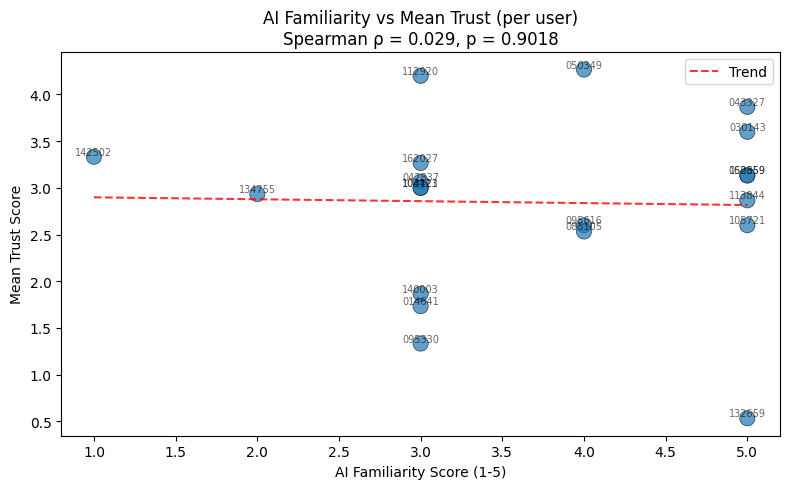

Mean scores by AI familiarity score:

                      trust_score  helpfulness_score  confidence_alignment
ai_familiarity_score                                                      
1                           3.333              3.067                 3.067
2                           2.933              3.200                 3.467
3                           2.683              1.825                 2.083
4                           3.133              2.222                 2.444
5                           2.819              2.705                 2.810


In [100]:
# AI familiarity score vs trust (scatter with per-user aggregation)
user_level = dfm.groupby("user_id").agg(
    mean_trust=("trust_score", "mean"),
    mean_helpfulness=("helpfulness_score", "mean"),
    mean_conf_align=("confidence_alignment", "mean"),
    ai_familiarity=("ai_familiarity_score", "first"),
    ai_usage=("ai_usage_frequency", "first"),
    age=("age_range", "first"),
    education=("education_level", "first"),
    n_responses=("trust_score", "count")
).reset_index()

# Scatter: AI familiarity vs mean trust per user
plt.figure(figsize=(8, 5))
plt.scatter(user_level["ai_familiarity"], user_level["mean_trust"], 
            s=user_level["n_responses"] * 8, alpha=0.7, edgecolors="black", linewidth=0.5)

# Add user labels
for _, row in user_level.iterrows():
    plt.annotate(row["user_id"][-6:], (row["ai_familiarity"], row["mean_trust"]),
                 fontsize=7, alpha=0.6, ha="center", va="bottom")

# Trend line
z = np.polyfit(user_level["ai_familiarity"], user_level["mean_trust"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(user_level["ai_familiarity"].min(), user_level["ai_familiarity"].max(), 100)
plt.plot(x_line, p_line(x_line), "r--", alpha=0.8, label="Trend")

rho, pval = spearmanr(user_level["ai_familiarity"], user_level["mean_trust"])
plt.title(f"AI Familiarity vs Mean Trust (per user)\nSpearman ρ = {rho:.3f}, p = {pval:.4f}")
plt.xlabel("AI Familiarity Score (1-5)")
plt.ylabel("Mean Trust Score")
plt.legend()
plt.tight_layout()
plt.show()

# Group by familiarity score bins
fam_scores = dfm.groupby("ai_familiarity_score")[score_cols].mean()
print("Mean scores by AI familiarity score:\n")
print(fam_scores.round(3))

## 22. Education Level vs Trust
Does the participant's **education level** (undergraduate student, postgraduate student, working professional, other) affect their trust calibration? Professionals and postgraduates may apply more critical thinking to LLM outputs.

Mean scores by education level:

                       trust_score  helpfulness_score  confidence_alignment
education_level                                                            
Other                        2.367              2.500                 3.100
Postgraduate student         3.133              2.978                 3.133
Undergraduate student        3.578              2.867                 2.822
Working professional         2.667              1.994                 2.178


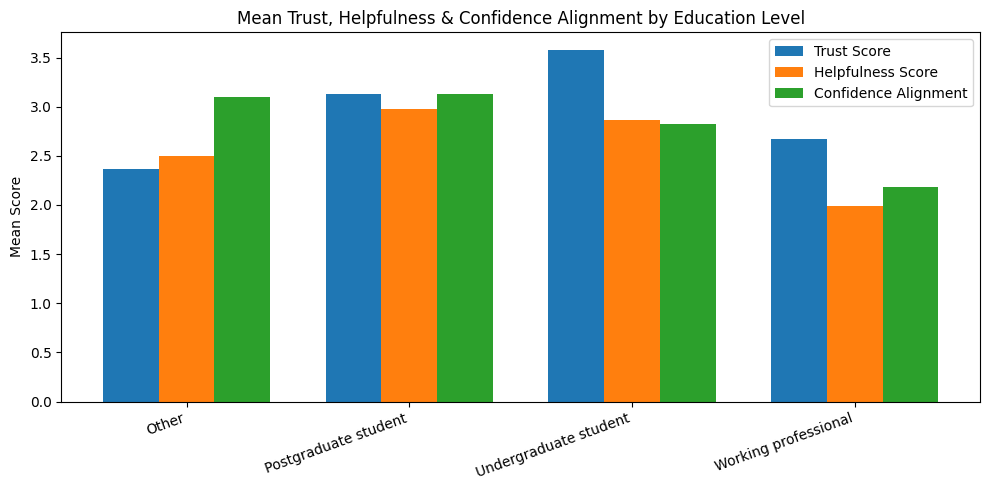

C:\Users\madevada\AppData\Local\Temp\ipykernel_45852\1483643745.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(edu_groups, labels=edu_levels)


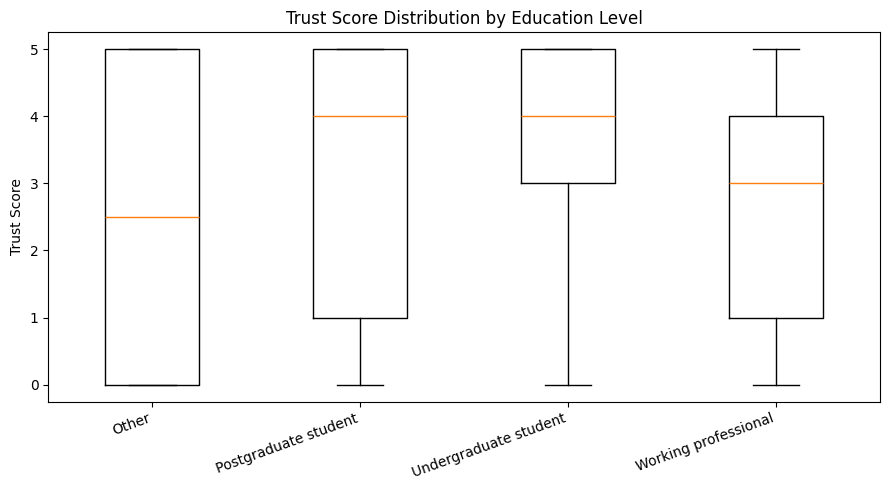


Responses per education level:
education_level
Working professional     180
Postgraduate student      45
Undergraduate student     45
Other                     30
Name: count, dtype: int64


In [101]:
# Mean scores by education level
edu_scores = dfm.groupby("education_level")[score_cols].mean()
print("Mean scores by education level:\n")
print(edu_scores.round(3))

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(edu_scores.index))
width = 0.25

for i, col in enumerate(score_cols):
    ax.bar(x + i * width, edu_scores[col], width, label=col.replace("_", " ").title())

ax.set_xticks(x + width)
ax.set_xticklabels(edu_scores.index, rotation=20, ha="right")
ax.set_ylabel("Mean Score")
ax.set_title("Mean Trust, Helpfulness & Confidence Alignment by Education Level")
ax.legend()
plt.tight_layout()
plt.show()

# Box plot
fig, ax = plt.subplots(figsize=(9, 5))
edu_levels = sorted(dfm["education_level"].dropna().unique())
edu_groups = [dfm[dfm["education_level"] == e]["trust_score"].dropna() for e in edu_levels]
ax.boxplot(edu_groups, labels=edu_levels)
ax.set_title("Trust Score Distribution by Education Level")
ax.set_ylabel("Trust Score")
ax.set_xticklabels(edu_levels, rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("\nResponses per education level:")
print(dfm["education_level"].value_counts())

## 23. English Proficiency vs Trust
Since the study is in English, participants' **language proficiency** may affect how well they understand (and trust) the LLM explanations. Non-native speakers might interpret outputs differently.

Mean scores by English proficiency:

                                        trust_score  helpfulness_score  \
english_proficiency                                                      
English is my first language                  3.417              1.933   
English is my primary working language        2.682              2.405   
English is not my primary language            2.778              2.489   

                                        confidence_alignment  
english_proficiency                                           
English is my first language                           1.900  
English is my primary working language                 2.682  
English is not my primary language                     2.578  


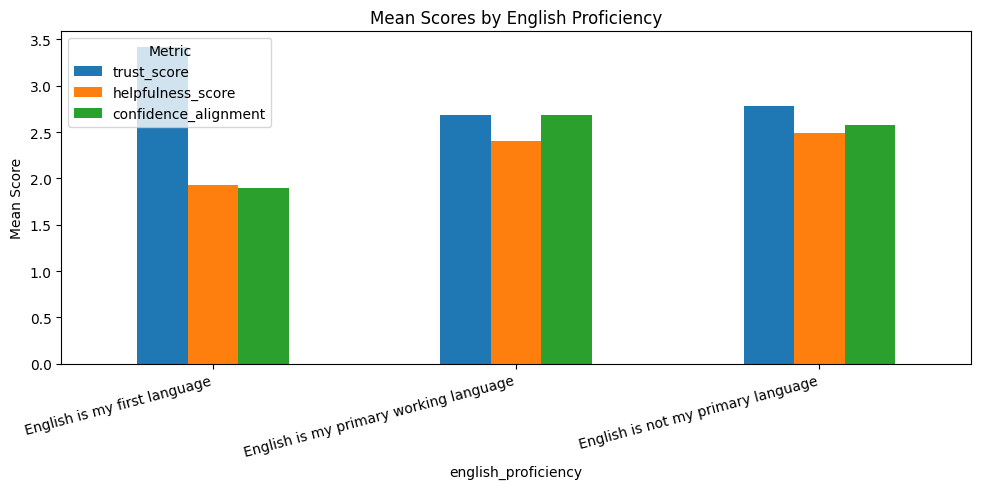


Preferred answer type (%) by English proficiency:

preferred_answer                        Answer only  Answer with explanation  \
english_proficiency                                                            
English is my first language                   68.3                     20.0   
English is my primary working language         40.5                     49.7   
English is not my primary language             37.8                     55.6   

preferred_answer                        Disagree with both  
english_proficiency                                         
English is my first language                          11.7  
English is my primary working language                 9.7  
English is not my primary language                     6.7  

Issue detection rate (%) by English proficiency:
english_proficiency
English is my first language              26.7
English is my primary working language    25.6
English is not my primary language        20.0
Name: issue_flag, dtype: float6

In [102]:
# Mean scores by English proficiency
eng_scores = dfm.groupby("english_proficiency")[score_cols].mean()
print("Mean scores by English proficiency:\n")
print(eng_scores.round(3))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
eng_scores.plot(kind="bar", ax=ax)
ax.set_title("Mean Scores by English Proficiency")
ax.set_ylabel("Mean Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# Preferred answer by English proficiency
pref_by_eng = pd.crosstab(dfm["english_proficiency"], dfm["preferred_answer"], normalize="index") * 100
print("\nPreferred answer type (%) by English proficiency:\n")
print(pref_by_eng.round(1))

# Issue rate by English proficiency
issue_by_eng = dfm.groupby("english_proficiency")["issue_flag"].mean() * 100
print("\nIssue detection rate (%) by English proficiency:")
print(issue_by_eng.round(1))

## 24. Comprehensive User Profile Heatmap
A single heatmap showing each user's **mean trust**, along with their demographic and AI background attributes, to provide a holistic view of how user profiles relate to trust.

Comprehensive User Profile Summary
             user_id   age             education     ai_usage  ai_familiarity  n_responses  mean_trust  mean_helpfulness  mean_conf_align  issue_rate  pct_explanation
user_20260222_140003   45+                 Other Occasionally               3           15        1.87              1.73             1.80       40.00            73.33
user_20260222_142502   45+  Postgraduate student Occasionally               1           15        3.33              3.07             3.07       13.33            60.00
user_20260223_162027 35-44  Working professional        Daily               3           15        3.27              1.13             3.20        6.67            33.33
user_20260225_042837   45+  Working professional        Daily               3           15        3.07              2.93             2.87       33.33            66.67
user_20260225_043327 18-24 Undergraduate student        Daily               5           15        3.87              3.07          

C:\Users\madevada\AppData\Local\Temp\ipykernel_45852\1955907719.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  user_summary["pct_explanation"] = dfm.groupby("user_id").apply(


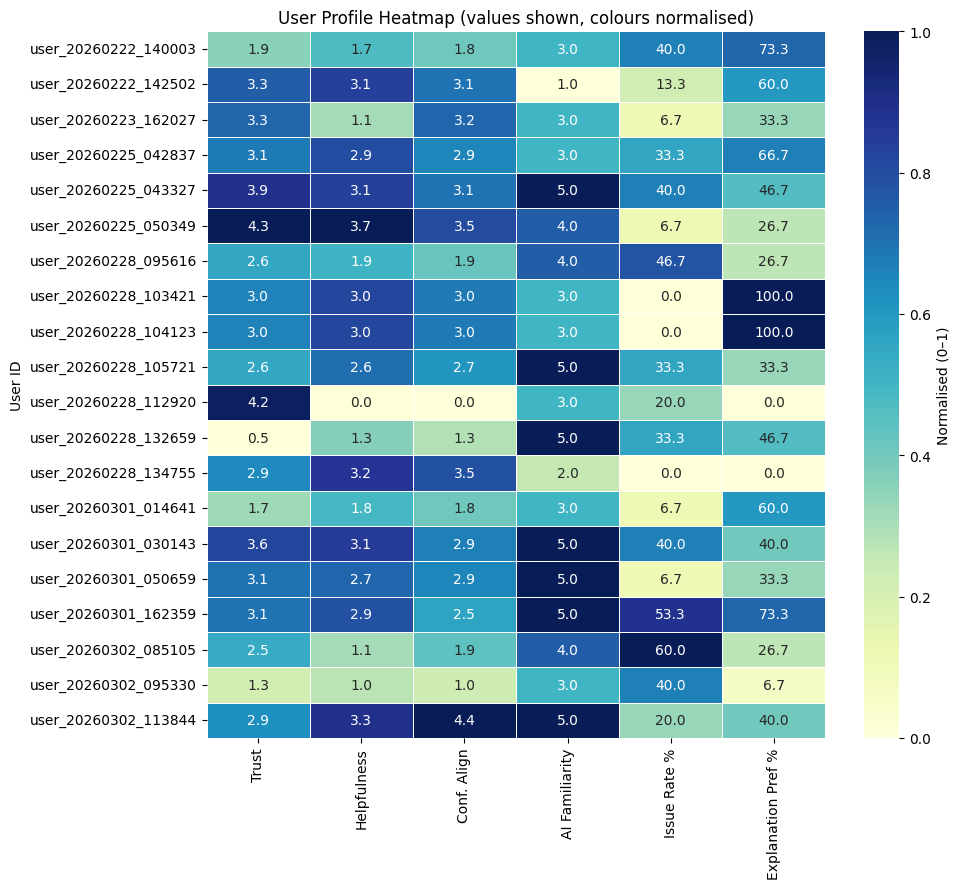

In [103]:
# Comprehensive user-level summary table
user_summary = user_level.copy()
user_summary["issue_rate"] = dfm.groupby("user_id")["issue_flag"].mean().values * 100
user_summary["pct_explanation"] = dfm.groupby("user_id").apply(
    lambda g: (g["preferred_answer"] == "Answer with explanation").mean() * 100
).values

# Display the full user profile table
display_cols = ["user_id", "age", "education", "ai_usage", "ai_familiarity",
                "n_responses", "mean_trust", "mean_helpfulness", "mean_conf_align",
                "issue_rate", "pct_explanation"]
print("Comprehensive User Profile Summary")
print("=" * 100)
print(user_summary[display_cols].round(2).to_string(index=False))

# Heatmap of numeric columns per user
heatmap_data = user_summary.set_index("user_id")[
    ["mean_trust", "mean_helpfulness", "mean_conf_align", "ai_familiarity", "issue_rate", "pct_explanation"]
]
heatmap_data.columns = ["Trust", "Helpfulness", "Conf. Align", "AI Familiarity", "Issue Rate %", "Explanation Pref %"]

# Normalize each column to 0-1 for heatmap colour scale
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(10, max(6, len(heatmap_norm) * 0.45)))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(1).values, fmt="", 
            cmap="YlGnBu", linewidths=0.5, cbar_kws={"label": "Normalised (0–1)"})
plt.title("User Profile Heatmap (values shown, colours normalised)")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

---

# Formal Statistical Tests

## Study Design & Sample Size Considerations

We have **N = 20 participants**, each rating ~15 questions across **3 conditions** (datasets: CoSE, eSNLI, TruthfulQA). This is a **within-subjects (repeated-measures) design**, since every participant sees all three conditions.

### Is n = 16 problematic?
- The original proposal targeted 20–30 participants. With 16, we are slightly below that range.
- However, in a **within-subjects** design, each participant serves as their own control, which is substantially more powerful than between-subjects. A within-subjects design with n = 16 has comparable power to a between-subjects design with n ≈ 40–50 (Cohen, 1988).
- With ~15 observations per participant, we have **~300 total data points**, which gives the mixed-effects models adequate data at the observation level.
- We **can** detect **medium effect sizes** (Cohen's d ≈ 0.5, η² ≈ 0.06) with reasonable power (~0.70–0.80) at α = 0.05 with n = 20 in a within-subjects design.
- **Limitation to acknowledge**: We may lack power to detect **small** effects (d < 0.3). This should be stated as a limitation in the thesis.
- **Recommendation**: Report effect sizes (η², Cohen's d, Kendall's W) alongside p-values, so readers can judge practical significance even when statistical significance is borderline.

### Tests we will apply:
1. **Friedman Test** — Non-parametric repeated-measures test for Likert-scale trust/helpfulness ratings across 3 conditions (Fisher, 1935; Friedman, 1937)
2. **Repeated-Measures ANOVA** — Parametric alternative treating Likert data as approximately continuous (with Mauchly's sphericity test + Greenhouse-Geisser correction)
3. **Mixed-Effects Linear Regression** — Fixed effect of condition (dataset), random effects of participant and question (Gelman & Hill, 2006)
4. **Effect Sizes** — Kendall's W (Friedman), partial η² (RM-ANOVA), and post-hoc power analysis
5. **Pairwise Comparisons** — Wilcoxon signed-rank tests with Bonferroni correction for multiple comparisons

## 25. Friedman Test — Non-Parametric Repeated Measures
The **Friedman test** (Friedman, 1937) is the non-parametric equivalent of repeated-measures ANOVA. It is appropriate for ordinal/Likert data where each participant provides ratings under all conditions.

- Each participant's **mean score per dataset** is computed, forming a participant × condition matrix.
- H₀: The distributions of ratings are the same across all 3 datasets.
- H₁: At least one dataset differs.
- We also compute **Kendall's W** (effect size): W = χ²_F / (N × (k-1)), where W ∈ [0,1].

In [104]:
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

# Build participant × condition matrix (mean score per user per dataset)
datasets_sorted = sorted(df["dataset"].unique())
n_conditions = len(datasets_sorted)

print("=" * 70)
print("FRIEDMAN TEST — Repeated Measures (Non-Parametric)")
print("=" * 70)

for outcome in score_cols:
    print(f"\n{'─' * 60}")
    print(f"Outcome: {outcome.replace('_', ' ').title()}")
    print(f"{'─' * 60}")
    
    # Pivot to participant × condition
    pivot = dfm.pivot_table(values=outcome, index="user_id", columns="dataset", aggfunc="mean")
    pivot = pivot.dropna()  # need complete cases for Friedman
    
    n_participants = len(pivot)
    print(f"Complete cases (participants with all 3 datasets): {n_participants}")
    
    if n_participants < 3:
        print("  ⚠ Too few complete cases for Friedman test.")
        continue
    
    # Extract groups
    groups = [pivot[ds].values for ds in datasets_sorted]
    
    # Friedman test
    chi2, p_friedman = friedmanchisquare(*groups)
    
    # Kendall's W (effect size)
    kendall_w = chi2 / (n_participants * (n_conditions - 1))
    
    # Effect size interpretation
    if kendall_w < 0.1:
        w_interp = "negligible"
    elif kendall_w < 0.3:
        w_interp = "small"
    elif kendall_w < 0.5:
        w_interp = "medium"
    else:
        w_interp = "large"
    
    sig = "✓ Significant" if p_friedman < 0.05 else "✗ Not significant"
    
    print(f"  χ²({n_conditions - 1}) = {chi2:.3f},  p = {p_friedman:.4f}  →  {sig}")
    print(f"  Kendall's W = {kendall_w:.3f}  ({w_interp} effect)")
    
    for ds in datasets_sorted:
        vals = pivot[ds]
        print(f"    {ds:12s}  mean={vals.mean():.2f}  median={vals.median():.2f}  sd={vals.std():.2f}")
    
    # Post-hoc pairwise Wilcoxon signed-rank tests with Bonferroni correction
    if p_friedman < 0.05:
        print(f"\n  Post-hoc Wilcoxon signed-rank tests (Bonferroni α = {0.05 / 3:.4f}):")
        n_comparisons = n_conditions * (n_conditions - 1) // 2
        bonferroni_alpha = 0.05 / n_comparisons
        
        for ds_a, ds_b in combinations(datasets_sorted, 2):
            a_vals = pivot[ds_a].values
            b_vals = pivot[ds_b].values
            
            # Check if there's any difference
            if np.all(a_vals == b_vals):
                print(f"    {ds_a} vs {ds_b}: identical values, no test needed")
                continue
                
            stat_w, p_w = wilcoxon(a_vals, b_vals)
            sig_w = "✓ Sig" if p_w < bonferroni_alpha else "✗ NS"
            # Effect size r = Z / sqrt(N)
            from scipy.stats import norm
            z_val = norm.ppf(1 - p_w / 2)
            r_effect = z_val / np.sqrt(n_participants)
            print(f"    {ds_a} vs {ds_b}:  W={stat_w:.1f}  p={p_w:.4f}  r={r_effect:.3f}  {sig_w}")
    else:
        print("  (No post-hoc tests needed — Friedman was not significant)")

FRIEDMAN TEST — Repeated Measures (Non-Parametric)

────────────────────────────────────────────────────────────
Outcome: Trust Score
────────────────────────────────────────────────────────────
Complete cases (participants with all 3 datasets): 20
  χ²(2) = 11.681,  p = 0.0029  →  ✓ Significant
  Kendall's W = 0.292  (small effect)
    CoSE          mean=3.16  median=3.10  sd=1.05
    TruthfulQA    mean=3.10  median=3.60  sd=1.24
    eSNLI         mean=2.27  median=2.40  sd=1.11

  Post-hoc Wilcoxon signed-rank tests (Bonferroni α = 0.0167):
    CoSE vs TruthfulQA:  W=66.0  p=0.9176  r=0.023  ✗ NS
    CoSE vs eSNLI:  W=23.0  p=0.0064  r=0.609  ✓ Sig
    TruthfulQA vs eSNLI:  W=22.0  p=0.0098  r=0.577  ✓ Sig

────────────────────────────────────────────────────────────
Outcome: Helpfulness Score
────────────────────────────────────────────────────────────
Complete cases (participants with all 3 datasets): 20
  χ²(2) = 1.937,  p = 0.3797  →  ✗ Not significant
  Kendall's W = 0.048  (neg

## 26. Repeated-Measures ANOVA (Parametric Approach)
Treating Likert scores as approximately continuous (a common and defensible approach when the scale has 5+ levels), we run a **one-way repeated-measures ANOVA** (Fisher, 1935) with dataset as the within-subjects factor.

- **Mauchly's test** checks the sphericity assumption.
- If sphericity is violated, we apply the **Greenhouse-Geisser correction**.
- We report **partial η²** as the effect size (small ≥ 0.01, medium ≥ 0.06, large ≥ 0.14).

In [105]:
try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    HAS_PINGOUIN = False
    print("⚠ pingouin not installed. Installing now...")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pingouin", "-q"])
    import pingouin as pg
    HAS_PINGOUIN = True

print("=" * 70)
print("REPEATED-MEASURES ANOVA (Parametric)")
print("=" * 70)

for outcome in score_cols:
    print(f"\n{'─' * 60}")
    print(f"Outcome: {outcome.replace('_', ' ').title()}")
    print(f"{'─' * 60}")
    
    # Need long-format data with user_id and dataset
    anova_data = dfm[["user_id", "dataset", outcome]].dropna()
    
    # Aggregate to mean per user per dataset (one value per cell)
    anova_agg = anova_data.groupby(["user_id", "dataset"])[outcome].mean().reset_index()
    
    # Only keep users with all 3 conditions
    user_counts = anova_agg.groupby("user_id")["dataset"].count()
    complete_users = user_counts[user_counts == n_conditions].index
    anova_agg = anova_agg[anova_agg["user_id"].isin(complete_users)]
    
    n_complete = len(complete_users)
    print(f"Complete cases: {n_complete} participants")
    
    if n_complete < 3:
        print("  ⚠ Too few complete cases.")
        continue
    
    # Repeated-measures ANOVA
    rm_aov = pg.rm_anova(data=anova_agg, dv=outcome, within="dataset", subject="user_id",
                         correction=True, detailed=True)
    
    print(rm_aov.to_string(index=False))
    
    # Sphericity test
    spher = pg.sphericity(data=anova_agg, dv=outcome, within="dataset", subject="user_id")
    print(f"\n  Mauchly's sphericity: W = {spher[1]:.3f}, p = {spher[2]:.4f}", end="")
    if spher[0]:
        print(" → Sphericity assumed ✓")
    else:
        print(" → Sphericity violated ✗ (use Greenhouse-Geisser correction)")
    
    # Effect size interpretation
    eta2 = rm_aov["np2"].iloc[0] if "np2" in rm_aov.columns else None
    if eta2 is not None:
        if eta2 < 0.01:
            eta_interp = "negligible"
        elif eta2 < 0.06:
            eta_interp = "small"
        elif eta2 < 0.14:
            eta_interp = "medium"
        else:
            eta_interp = "large"
        print(f"  Partial η² = {eta2:.3f} ({eta_interp} effect)")
    
    # Post-hoc pairwise t-tests with Bonferroni correction
    p_val = rm_aov["p-unc"].iloc[0] if "p-unc" in rm_aov.columns else rm_aov["p-GG-corr"].iloc[0]
    if p_val < 0.05:
        print("\n  Post-hoc pairwise t-tests (Bonferroni corrected):")
        posthoc = pg.pairwise_tests(data=anova_agg, dv=outcome, within="dataset", 
                                     subject="user_id", padjust="bonf")
        print(posthoc[["Contrast", "A", "B", "T", "dof", "p-unc", "p-corr", "hedges"]].to_string(index=False))
    else:
        print("  (No post-hoc tests — ANOVA was not significant)")

⚠ pingouin not installed. Installing now...
REPEATED-MEASURES ANOVA (Parametric)

────────────────────────────────────────────────────────────
Outcome: Trust Score
────────────────────────────────────────────────────────────
Complete cases: 20 participants
 Source        SS  DF       MS        F    p-unc  p-GG-corr      ng2      eps sphericity  W-spher  p-spher
dataset  9.897333   2 4.948667 7.439838 0.001877    0.00188 0.118153 0.999496       True 0.999496 0.995471
  Error 25.276000  38 0.665158      NaN      NaN        NaN      NaN      NaN        NaN      NaN      NaN

  Mauchly's sphericity: W = 0.999, p = 0.0091 → Sphericity assumed ✓

  Post-hoc pairwise t-tests (Bonferroni corrected):
Contrast          A          B        T  dof    p-unc   p-corr   hedges
 dataset       CoSE TruthfulQA 0.232956 19.0 0.818287 1.000000 0.051060
 dataset       CoSE      eSNLI 3.415771 19.0 0.002899 0.008697 0.806367
 dataset TruthfulQA      eSNLI 3.247518 19.0 0.004237 0.012712 0.689736

──────────

## 27. Mixed-Effects Linear Regression
Following **Gelman & Hill (2006)**, we fit a **linear mixed-effects model** with:
- **Fixed effect**: `dataset` (condition: CoSE, eSNLI, TruthfulQA)
- **Random intercepts**: `user_id` (participant) and `question_id` (item)

This approach accounts for the **nested structure** of the data (responses within participants, responses within questions) and is robust to unbalanced designs. It uses all individual observations rather than collapsing to means, giving greater statistical power.

In [106]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning if 'ConvergenceWarning' in dir() else UserWarning)

print("=" * 70)
print("MIXED-EFFECTS LINEAR REGRESSION (Gelman & Hill, 2006)")
print("=" * 70)

for outcome in score_cols:
    print(f"\n{'─' * 60}")
    print(f"Outcome: {outcome.replace('_', ' ').title()}")
    print(f"{'─' * 60}")
    
    # Prepare data
    lmm_data = dfm[["user_id", "question_id", "dataset", outcome]].dropna()
    
    # Ensure question_id is string for grouping
    lmm_data["question_id"] = lmm_data["question_id"].astype(str)
    
    print(f"  Observations: {len(lmm_data)}")
    print(f"  Participants: {lmm_data['user_id'].nunique()}")
    print(f"  Questions: {lmm_data['question_id'].nunique()}")
    
    # Fit mixed-effects model: outcome ~ dataset + (1|user_id) + (1|question_id)
    try:
        model = smf.mixedlm(
            f"{outcome} ~ C(dataset, Treatment('CoSE'))",
            data=lmm_data,
            groups=lmm_data["user_id"],
            # Add question as variance component
            vc_formula={"question_id": "0 + C(question_id)"}
        )
        result = model.fit(reml=True)
        
        print(f"\n{result.summary()}\n")
        
        # Extract key results
        print("  Fixed effects interpretation:")
        for param in result.params.index:
            if "dataset" in param.lower() or "intercept" in param.lower():
                coef = result.params[param]
                pval = result.pvalues[param]
                ci = result.conf_int().loc[param]
                sig = "✓" if pval < 0.05 else "✗"
                print(f"    {param:40s}  β={coef:+.3f}  p={pval:.4f}  95%CI=[{ci[0]:.3f}, {ci[1]:.3f}]  {sig}")
        
        # Random effects variance
        print(f"\n  Random effects:")
        print(f"    Participant (user_id) variance: {result.cov_re.iloc[0, 0]:.3f}")
        
    except Exception as e:
        # Fallback: simpler model without question random effect
        print(f"  Note: Full model failed ({str(e)[:60]}...), fitting simpler model...")
        try:
            model = smf.mixedlm(
                f"{outcome} ~ C(dataset, Treatment('CoSE'))",
                data=lmm_data,
                groups=lmm_data["user_id"]
            )
            result = model.fit(reml=True)
            print(f"\n{result.summary()}\n")
            
            print("  Fixed effects interpretation:")
            for param in result.params.index:
                if "dataset" in param.lower() or "intercept" in param.lower():
                    coef = result.params[param]
                    pval = result.pvalues[param]
                    ci = result.conf_int().loc[param]
                    sig = "✓" if pval < 0.05 else "✗"
                    print(f"    {param:40s}  β={coef:+.3f}  p={pval:.4f}  95%CI=[{ci[0]:.3f}, {ci[1]:.3f}]  {sig}")
            
            print(f"\n  Random effects:")
            print(f"    Participant (user_id) variance: {result.cov_re.iloc[0, 0]:.3f}")
        except Exception as e2:
            print(f"  ⚠ Model failed: {e2}")

MIXED-EFFECTS LINEAR REGRESSION (Gelman & Hill, 2006)

────────────────────────────────────────────────────────────
Outcome: Trust Score
────────────────────────────────────────────────────────────
  Observations: 300
  Participants: 20
  Questions: 178

                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          trust_score
No. Observations:            300              Method:                      REML       
No. Groups:                  20               Scale:                       1.6063     
Min. group size:             15               Log-Likelihood:              -601.6452  
Max. group size:             15               Converged:                   Yes        
Mean group size:             15.0                                                     
--------------------------------------------------------------------------------------
                                            Coef.  Std.Err.   z    P>|z| [

## 28. Post-Hoc Power Analysis & Effect Size Summary
With n = 16 in a within-subjects design, we calculate:
1. **Observed effect sizes** from our tests above
2. **Achieved power** — the probability of detecting the observed effect given our sample
3. A **summary table** consolidating all statistical test results

This helps us honestly assess whether non-significant results reflect a true null or simply insufficient power (Type II error).

In [110]:
from scipy.stats import f as f_dist

print("=" * 70)
print("POST-HOC POWER ANALYSIS & EFFECT SIZE SUMMARY")
print("=" * 70)

# Collect results from all tests
summary_rows = []

for outcome in score_cols:
    # Friedman test
    pivot = dfm.pivot_table(values=outcome, index="user_id", columns="dataset", aggfunc="mean").dropna()
    n_p = len(pivot)
    
    if n_p >= 3:
        groups = [pivot[ds].values for ds in datasets_sorted]
        chi2, p_friedman = friedmanchisquare(*groups)
        kendall_w = chi2 / (n_p * (n_conditions - 1))
        
        summary_rows.append({
            "Outcome": outcome.replace("_", " ").title(),
            "Test": "Friedman",
            "Statistic": f"χ²={chi2:.3f}",
            "p-value": f"{p_friedman:.4f}",
            "Effect Size": f"W={kendall_w:.3f}",
            "Interpretation": "small" if kendall_w < 0.3 else ("medium" if kendall_w < 0.5 else "large"),
            "Significant": "Yes" if p_friedman < 0.05 else "No",
            "N": n_p
        })
    
    # RM-ANOVA
    anova_agg = dfm.groupby(["user_id", "dataset"])[outcome].mean().reset_index()
    user_counts = anova_agg.groupby("user_id")["dataset"].count()
    complete_users = user_counts[user_counts == n_conditions].index
    anova_agg_complete = anova_agg[anova_agg["user_id"].isin(complete_users)]
    
    if len(complete_users) >= 3:
        rm_aov = pg.rm_anova(data=anova_agg_complete, dv=outcome, within="dataset", 
                              subject="user_id", correction=True, detailed=False)
        # pingouin returns 'ng2' (generalised η²); fall back to 'np2' if present
        eta2_col = "np2" if "np2" in rm_aov.columns else "ng2"
        eta2 = rm_aov[eta2_col].iloc[0]
        f_val = rm_aov["F"].iloc[0]
        p_anova = rm_aov["p-unc"].iloc[0]
        
        # Post-hoc power calculation for RM-ANOVA
        # Cohen's f = sqrt(η² / (1 - η²))
        cohens_f = np.sqrt(eta2 / (1 - eta2)) if eta2 < 1 else 0
        
        # Approximate power using non-central F distribution
        df1 = n_conditions - 1
        df2 = (n_p - 1) * (n_conditions - 1)
        ncp = cohens_f**2 * n_p * n_conditions  # non-centrality parameter
        f_crit = f_dist.ppf(0.95, df1, df2)
        power = 1 - f_dist.cdf(f_crit, df1, df2, ncp)
        
        summary_rows.append({
            "Outcome": outcome.replace("_", " ").title(),
            "Test": "RM-ANOVA",
            "Statistic": f"F={f_val:.3f}",
            "p-value": f"{p_anova:.4f}",
            "Effect Size": f"η²={eta2:.3f}, f={cohens_f:.3f}",
            "Interpretation": "small" if eta2 < 0.06 else ("medium" if eta2 < 0.14 else "large"),
            "Significant": "Yes" if p_anova < 0.05 else "No",
            "N": len(complete_users),
            "Power": f"{power:.2f}"
        })

# Display summary table
summary_df = pd.DataFrame(summary_rows)
print("\nConsolidated Statistical Test Results:")
print("=" * 120)
print(summary_df.to_string(index=False))

# Power analysis interpretation
print("\n" + "=" * 70)
print("POWER ANALYSIS INTERPRETATION")
print("=" * 70)
print(f"""
Sample size: N = 16 (within-subjects design)
Conditions: k = {n_conditions} ({', '.join(datasets_sorted)})

Power guidelines (Cohen, 1988):
  - Power ≥ 0.80 is conventionally adequate
  - Power < 0.80 increases risk of Type II error (missing real effects)

Within-subjects advantage:
  - Each participant serves as their own control
  - N=16 within-subjects ≈ N=40-50 between-subjects (for medium effects)
  - With ~25 items per participant, we have {len(dfm)} total observations

Recommendation for thesis:
  - Report all effect sizes alongside p-values
  - Acknowledge n=16 as a limitation (below the proposed 20-30)
  - Note that within-subjects design partially compensates
  - Non-significant results with small effect sizes → likely true null
  - Non-significant results with medium/large effects → possible Type II error
""")

POST-HOC POWER ANALYSIS & EFFECT SIZE SUMMARY

Consolidated Statistical Test Results:
             Outcome     Test Statistic p-value       Effect Size Interpretation Significant  N Power
         Trust Score Friedman χ²=11.681  0.0029           W=0.292          small         Yes 20   NaN
         Trust Score RM-ANOVA   F=7.440  0.0019 η²=0.118, f=0.366         medium         Yes 20  1.00
   Helpfulness Score Friedman  χ²=1.937  0.3797           W=0.048          small          No 20   NaN
   Helpfulness Score RM-ANOVA   F=1.984  0.1515 η²=0.042, f=0.210          small          No 20  0.56
Confidence Alignment Friedman  χ²=6.576  0.0373           W=0.164          small         Yes 20   NaN
Confidence Alignment RM-ANOVA   F=2.746  0.0769 η²=0.050, f=0.230          small          No 20  0.94

POWER ANALYSIS INTERPRETATION

Sample size: N = 16 (within-subjects design)
Conditions: k = 3 (CoSE, TruthfulQA, eSNLI)

Power guidelines (Cohen, 1988):
  - Power ≥ 0.80 is conventionally adequate
  